In this project, I will use a GAN with Transformer blocks to generate realistic synthetic financial time-series data.

In [ ]:
import os
from pathlib import Path

os.chdir(Path('..').resolve())
import json
import logging
from pathlib import Path
from typing import Any, Dict

import pandas as pd
import torch

from src.data.data_loader import load_data
from src.evaluation.metrics import evaluate_generated_data
from src.models.generate_utils import generate_synthetic_data
from src.training.data_splitting import split_time_series
from src.training.train import train_gan, setup_distributed
from src.utils.config import load_or_create_config
from src.utils.setup import setup_environment
from src.utils.checkpoint import load_checkpoint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from src.models.model_factory import create_models
from src.data.preprocessing import create_sequences, normalize_data, denormalize_data
from src.evaluation.visualization import (
    pca_tsne_visualization,
    plot_comparisons_grid,
    plot_distributions
)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

In [2]:
config_path = "config/config.json"

config_path = Path(config_path).resolve()
config = load_or_create_config(config_path)

# Setup environment (creates directories from config paths)
setup_environment(config)

2025-07-02 17:54:19,609 - src.utils.config - INFO - Found configuration file in parent directory.
2025-07-02 17:54:19,610 - src.utils.config - INFO - Successfully loaded configuration.


In [3]:
# Paths
checkpoint_dir = Path(config['paths']['checkpoint_dir']).resolve()
output_dir = Path(config['paths']['output_dir']).resolve()
data_dir = Path(config['paths']['data_dir']).resolve()

# Load data
logger.info("Getting the data...")
data = load_data(
    tickers=config['tickers'],
    start_date=config['start_date'],
    end_date=config['end_date'],
    data_dir=data_dir
)
data

2025-07-02 17:54:19,620 - __main__ - INFO - Getting the data...
2025-07-02 17:54:19,621 - src.data.data_loader - INFO - Loading existing data for AAPL...
2025-07-02 17:54:19,630 - src.data.data_loader - INFO - Loading existing data for MSFT...
2025-07-02 17:54:19,635 - src.data.data_loader - INFO - Loading existing data for AMZN...
2025-07-02 17:54:19,640 - src.data.data_loader - INFO - Loading existing data for GOOGL...
2025-07-02 17:54:19,645 - src.data.data_loader - INFO - Loading existing data for MMM...
2025-07-02 17:54:19,651 - src.data.data_loader - INFO - Successfully loaded data with shape (5030, 7)


,date,open,close,low,high,volume,ticker
0,2020-01-02,74.059998,75.087502,73.797501,75.150002,135480400,AAPL
1,2020-01-03,74.287498,74.357498,74.125000,75.144997,146322800,AAPL
2,2020-01-06,73.447502,74.949997,73.187500,74.989998,118387200,AAPL
3,2020-01-07,74.959999,74.597504,74.370003,75.224998,108872000,AAPL
4,2020-01-08,74.290001,75.797501,74.290001,76.110001,132079200,AAPL
...,...,...,...,...,...,...,...
5025,2023-12-22,88.528427,88.904678,88.419731,89.807693,2728913,MMM
5026,2023-12-26,88.879601,90.392975,88.854515,90.794312,3332176,MMM
5027,2023-12-27,90.301003,90.919731,90.033447,91.220734,2922785,MMM
5028,2023-12-28,90.852844,91.714050,90.844482,92.123749,3360282,MMM


First, I will split the data into train, validation and test sets while being mindful of the dates. 

### Split the data

In [ ]:
train_data, val_data, test_data = split_time_series(data)
print("Train data:")
display(train_data)
print("Validation data:")
display(val_data)
print("Test data:")
display(test_data)

assert val_data.date.min() > train_data.date.max()
assert test_data.date.min() > val_data.date.max()

2025-07-02 17:54:19,684 - src.training.data_splitting - INFO - Data split sizes - Train: 3520, Val: 755, Test: 755


Train data:


,date,open,close,low,high,volume,ticker
0,2020-01-02,74.059998,75.087502,73.797501,75.150002,135480400,AAPL
1,2020-01-03,74.287498,74.357498,74.125000,75.144997,146322800,AAPL
2,2020-01-06,73.447502,74.949997,73.187500,74.989998,118387200,AAPL
3,2020-01-07,74.959999,74.597504,74.370003,75.224998,108872000,AAPL
4,2020-01-08,74.290001,75.797501,74.290001,76.110001,132079200,AAPL
...,...,...,...,...,...,...,...
3515,2022-10-11,90.719063,91.003342,90.259193,92.349495,3462898,MMM
3516,2022-10-12,90.777596,91.095322,90.510033,91.722404,3290196,MMM
3517,2022-10-13,89.882942,95.535118,89.523415,96.011703,5708149,MMM
3518,2022-10-14,95.535118,95.008362,94.356186,96.287628,4137323,MMM


Validation data:


,date,open,close,low,high,volume,ticker
0,2022-10-18,145.490005,143.750000,140.610001,146.699997,99136600,AAPL
1,2022-10-19,141.690002,143.860001,141.500000,144.949997,61758300,AAPL
2,2022-10-20,143.020004,143.389999,142.649994,145.889999,64522000,AAPL
3,2022-10-21,142.869995,147.270004,142.649994,147.850006,86548600,AAPL
4,2022-10-24,147.190002,149.449997,146.000000,150.229996,75981900,AAPL
...,...,...,...,...,...,...,...
750,2023-05-18,82.307693,83.311035,81.989967,83.478264,3485503,MMM
751,2023-05-19,83.821068,82.801003,82.500000,84.005020,3229080,MMM
752,2023-05-22,82.675583,85.041809,82.207359,85.317726,5008011,MMM
753,2023-05-23,85.041809,84.197327,84.163879,85.986626,4324975,MMM


Test data:


,date,open,close,low,high,volume,ticker
0,2023-05-25,172.410004,172.990005,171.690002,173.899994,56058300,AAPL
1,2023-05-26,173.320007,175.429993,173.110001,175.770004,54835000,AAPL
2,2023-05-30,176.960007,177.300003,176.570007,178.990005,55964400,AAPL
3,2023-05-31,177.330002,177.250000,176.759995,179.350006,99625300,AAPL
4,2023-06-01,177.699997,180.089996,176.929993,180.119995,68901800,AAPL
...,...,...,...,...,...,...,...
750,2023-12-22,88.528427,88.904678,88.419731,89.807693,2728913,MMM
751,2023-12-26,88.879601,90.392975,88.854515,90.794312,3332176,MMM
752,2023-12-27,90.301003,90.919731,90.033447,91.220734,2922785,MMM
753,2023-12-28,90.852844,91.714050,90.844482,92.123749,3360282,MMM


In [ ]:
def analyze_ticker_distribution(data):
    """Analyze how much data each ticker contributes"""
    
    train_data, val_data, test_data = split_time_series(data)
    
    print("Training Data Distribution:")
    train_counts = train_data['ticker'].value_counts()
    print(train_counts)
    print(f"Total training samples: {len(train_data)}")
    
    print("\nValidation Data Distribution:")
    val_counts = val_data['ticker'].value_counts()
    print(val_counts)
    print(f"Total validation samples: {len(val_data)}")
        
    print("\nTest Data Distribution:")
    test_counts = test_data['ticker'].value_counts()
    print(test_counts)
    print(f"Total test samples: {len(test_data)}")
    
    print(f"\nTraining period: {train_data['date'].min()} to {train_data['date'].max()}")
    print(f"Validation period: {val_data['date'].min()} to {val_data['date'].max()}")
    print(f"Test period: {test_data['date'].min()} to {test_data['date'].max()}")
    
    return train_counts, val_counts, test_counts

train_counts, val_counts, test_counts = analyze_ticker_distribution(data)


2025-07-02 17:58:33,196 - src.training.data_splitting - INFO - Data split sizes - Train: 3520, Val: 755, Test: 755


Training Data Distribution:
ticker
AAPL     704
MSFT     704
AMZN     704
GOOGL    704
MMM      704
Name: count, dtype: int64
Total training samples: 3520

Validation Data Distribution:
ticker
AAPL     151
MSFT     151
AMZN     151
GOOGL    151
MMM      151
Name: count, dtype: int64
Total validation samples: 755

Test Data Distribution:
ticker
AAPL     151
MSFT     151
AMZN     151
GOOGL    151
MMM      151
Name: count, dtype: int64
Total test samples: 755

Training period: 2020-01-02 00:00:00 to 2022-10-17 00:00:00
Validation period: 2022-10-18 00:00:00 to 2023-05-24 00:00:00
Test period: 2023-05-25 00:00:00 to 2023-12-29 00:00:00


In [ ]:
for ticker in ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'MMM']:
    ticker_data = test_data[test_data.ticker == ticker]
    print(f"{ticker} Volume Stats:")
    print(f"  Mean: {ticker_data['volume'].mean():,.0f}")
    print(f"  Median: {ticker_data['volume'].median():,.0f}")  
    print(f"  Min: {ticker_data['volume'].min():,.0f}")
    print(f"  Max: {ticker_data['volume'].max():,.0f}")
    print()

AAPL Volume Stats:
  Mean: 56,654,020
  Median: 53,003,900
  Min: 24,048,300
  Max: 128,256,700

MSFT Volume Stats:
  Mean: 25,779,255
  Median: 23,277,700
  Min: 10,176,600
  Max: 78,478,200

AMZN Volume Stats:
  Mean: 53,736,252
  Median: 49,653,500
  Min: 22,378,400
  Max: 152,938,700

GOOGL Volume Stats:
  Mean: 29,285,568
  Median: 26,762,900
  Min: 12,514,300
  Max: 84,366,200

MMM Volume Stats:
  Mean: 4,458,878
  Median: 3,883,890
  Min: 1,267,640
  Max: 16,938,828



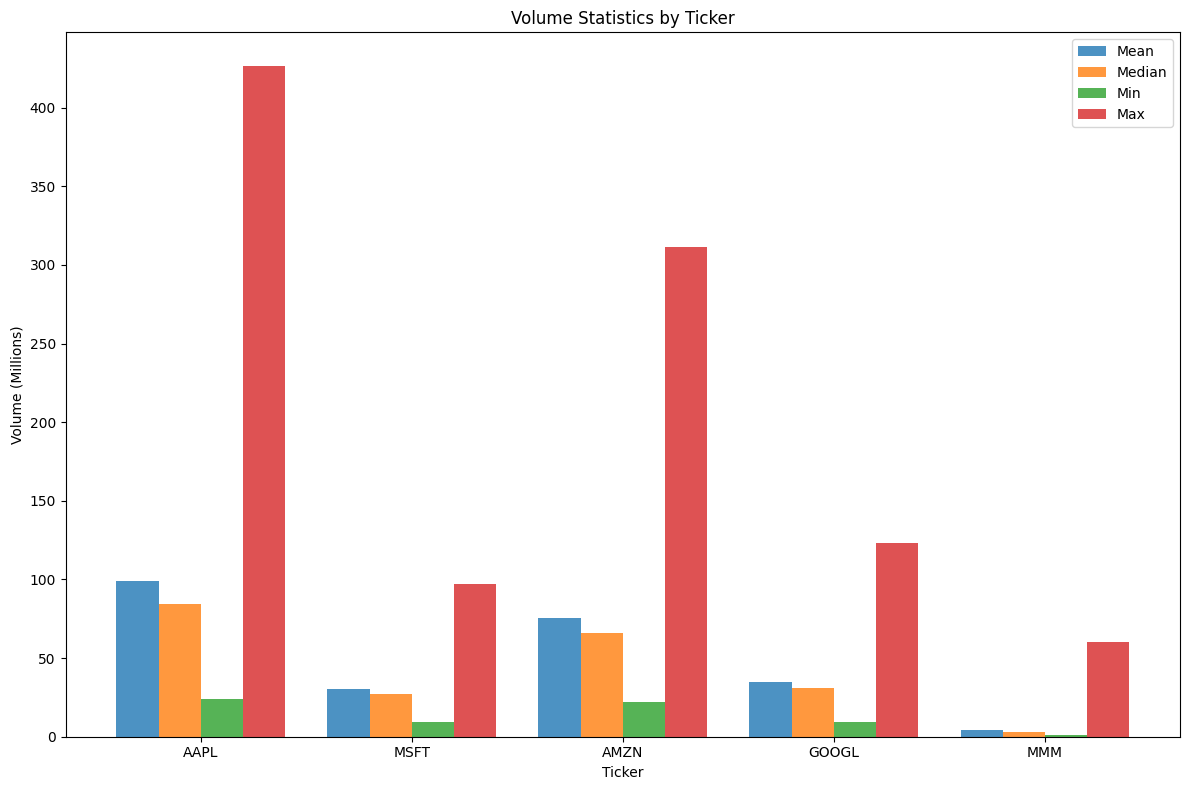

In [ ]:
def plot_volume_stats(test_data):
    """Plot the volume statistics being printed"""
    
    tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'MMM']
    
    stats = {}
    for ticker in tickers:
        ticker_data = test_data[test_data.ticker == ticker]
        stats[ticker] = {
            'Mean': ticker_data['volume'].mean(),
            'Median': ticker_data['volume'].median(),
            'Min': ticker_data['volume'].min(),
            'Max': ticker_data['volume'].max()
        }
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    x = np.arange(len(tickers))
    width = 0.2
    
    # Plot each metric
    means = [stats[ticker]['Mean']/1e6 for ticker in tickers]
    medians = [stats[ticker]['Median']/1e6 for ticker in tickers]
    mins = [stats[ticker]['Min']/1e6 for ticker in tickers]
    maxs = [stats[ticker]['Max']/1e6 for ticker in tickers]
    
    ax.bar(x - 1.5*width, means, width, label='Mean', alpha=0.8)
    ax.bar(x - 0.5*width, medians, width, label='Median', alpha=0.8)
    ax.bar(x + 0.5*width, mins, width, label='Min', alpha=0.8)
    ax.bar(x + 1.5*width, maxs, width, label='Max', alpha=0.8)
    
    ax.set_xlabel('Ticker')
    ax.set_ylabel('Volume (Millions)')
    ax.set_title('Volume Statistics by Ticker')
    ax.set_xticks(x)
    ax.set_xticklabels(tickers)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_volume_stats(data)

### Generating features

I will create new cyclic features out of the date features.

In [5]:
# Calculate model dimensions
n_cyclic = sum(2 for use_feature in config['data_params']['cyclic_features'].values() if use_feature)
print(n_cyclic)
n_ohlc = len(config['features']) - 1  # Subtract volume
print(n_ohlc)
n_volume = config['data_params']['n_volume_features']
input_size = n_ohlc + n_volume + n_cyclic
output_size = input_size
output_size

6
4


11

In [6]:
# Data preparation
tickers = data['ticker'].unique()
tickers

array(['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'MMM'], dtype=object)

### Normalize data

In [ ]:
tickers = data['ticker'].unique()
normalized_train = normalize_data(train_data, tickers, config['data_params']['cyclic_features'])
normalized_val = normalize_data(
    val_data, tickers, config['data_params']['cyclic_features']
)

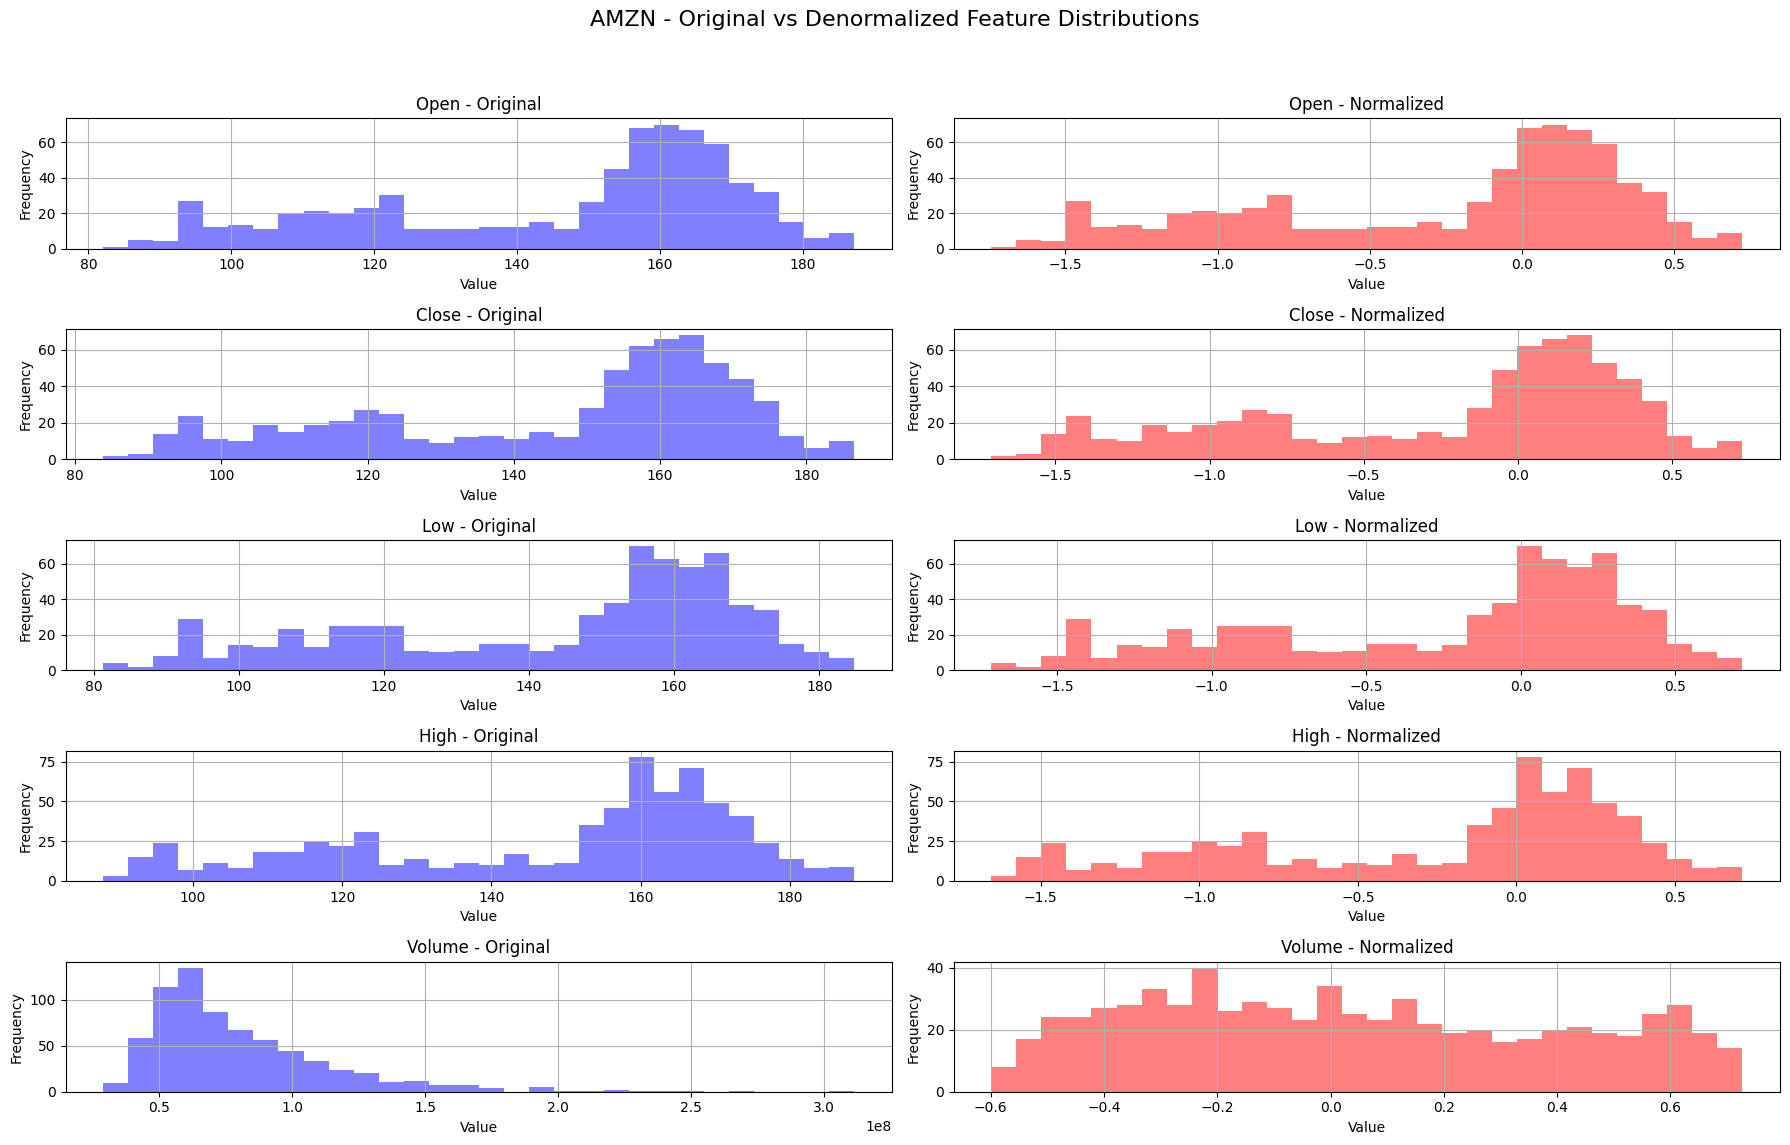

In [ ]:
def plot_data(normalized_data, raw_data, ticker, features, config, figsize=(18, 12)):
    """
    Plot original vs. denormalized feature distributions.
    
    Args:
        normalized_data: Normalized data dictionary returned by `normalize_data`.
        raw_data: Original DataFrame containing all features.
        ticker: Ticker symbol to filter the data.
        features: List of feature names (OHLC and volume) to compare.
        config: Configuration dictionary with normalization parameters.
        figsize: Tuple defining figure size.
    """
    # Extract normalized data for the given ticker
    ticker_data = normalized_data[ticker]
    norm_ohlc = ticker_data['norm_ohlc']
    norm_volume = ticker_data['norm_volume'].reshape(-1, 1)
    norm_params = ticker_data['norm_params']

    norm_features = np.hstack([norm_ohlc, norm_volume])
    norm_features_df = pd.DataFrame(norm_features, columns=features)

    # Filter the original data for the ticker
    original_data = raw_data[raw_data['ticker'] == ticker][features]

    # Plot distributions
    num_features = len(features)
    num_rows = (num_features + 1) // 2

    fig, axs = plt.subplots(num_rows * 2 - 1, 2, figsize=figsize)
    fig.suptitle(f"{ticker} - Original vs Denormalized Feature Distributions", fontsize=16)
    
    axs = axs.flatten()
    for idx, feature in enumerate(features):
        ax_orig = axs[idx*2]
        ax_norm = axs[idx*2 + 1]

        # Plot original feature distribution
        ax_orig.hist(original_data[feature], bins=30, alpha=0.5, label='Original', color='blue')
        ax_orig.set_title(f"{feature.capitalize()} - Original")
        ax_orig.set_xlabel('Value')
        ax_orig.set_ylabel('Frequency')
        ax_orig.grid(True)
        
        # Plot denormalized feature distribution
        ax_norm.hist(norm_features_df[feature], bins=30, alpha=0.5, label='Normalized', color='red')
        ax_norm.set_title(f"{feature.capitalize()} - Normalized")
        ax_norm.set_xlabel('Value')
        ax_norm.set_ylabel('Frequency')
        ax_norm.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

ticker = "AMZN"  
features = config["features"]
plot_data(normalized_data=normalized_train, raw_data=train_data, ticker=ticker, features=features, config=config)

In financial data, volume is often highly skewed — a few days of extreme trading activity dominate the scale. This is clear in the histogram above, where the majority of volume values cluster near the lower end, with a long right tail.

I applied a multi-stage normalization process for volume:

- log1p() transformation to reduce skew

- rolling z-score standardization to adapt to local trends

- RobustScaler to account for outliers

As seen in the normalized distribution, the result is roughly uniform spread of values, which helps when training neural networks.
This is especially important in GANs, where stable training requires input features to be both centered and consistent over time.

### Sequence creation

To train a model on time-series data, I first transformed each ticker's historical records into sequences. A sequence is a short window of consecutive days — for example, 10 days of OHLC, volume, and date features. Each sequence captures a small piece of the stock's timeline.

If sequence_length = 5:

Day 1: [ohlc features + volume + date features]

Day 2: [ohlc features + volume + date features]

Day 3: [ohlc features + volume + date features]

Day 4: [ohlc features + volume + date features]

Day 5: [ohlc features + volume + date features]

Day 6: [ohlc features + volume + date features]

Then sequences are created as:

Input sequence: Days 1–5 → Target: Day 6

Input sequence: Days 2–6 → Target: Day 7
etc.

In [9]:
sequence_length=config['sequence_length']
print(sequence_length)
train_sequences, train_targets = create_sequences(normalized_train, sequence_length)
val_sequences, val_targets = create_sequences(normalized_val, sequence_length)

10


Sequences are created from  stacked OHLC, volume and dates data:

```
combined_data = np.hstack([
            data['norm_ohlc'],
            data['norm_volume'].reshape(-1, 1),
            data['cyclic_dates']
        ])
```

In [10]:
train_sequences['AAPL'].shape

(694, 10, 11)

In [11]:
normalized_train['AAPL'].keys()

dict_keys(['raw_data_ohlc', 'raw_data_volume', 'norm_ohlc', 'norm_volume', 'cyclic_dates', 'norm_params'])

In [12]:
normalized_train['AAPL']['norm_ohlc']

array([[-1.63989369, -1.62236232, -1.58777512, -1.61883595],
       [-1.63367314, -1.64247918, -1.57894705, -1.61897082],
       [-1.65664112, -1.62615156, -1.60421829, -1.62314756],
       ...,
       [ 0.02611257,  0.24884187,  0.04501645,  0.2254109 ],
       [ 0.28094866,  0.12180307,  0.14798853,  0.25047175],
       [ 0.19235776,  0.23285863,  0.20405704,  0.20681746]])

In [13]:
normalized_train['AAPL'].keys()

dict_keys(['raw_data_ohlc', 'raw_data_volume', 'norm_ohlc', 'norm_volume', 'cyclic_dates', 'norm_params'])

In [14]:
train_sequences['AAPL'].shape

(694, 10, 11)

In [15]:
train_sequences['AAPL'][0].shape

(10, 11)

### Check denormalization

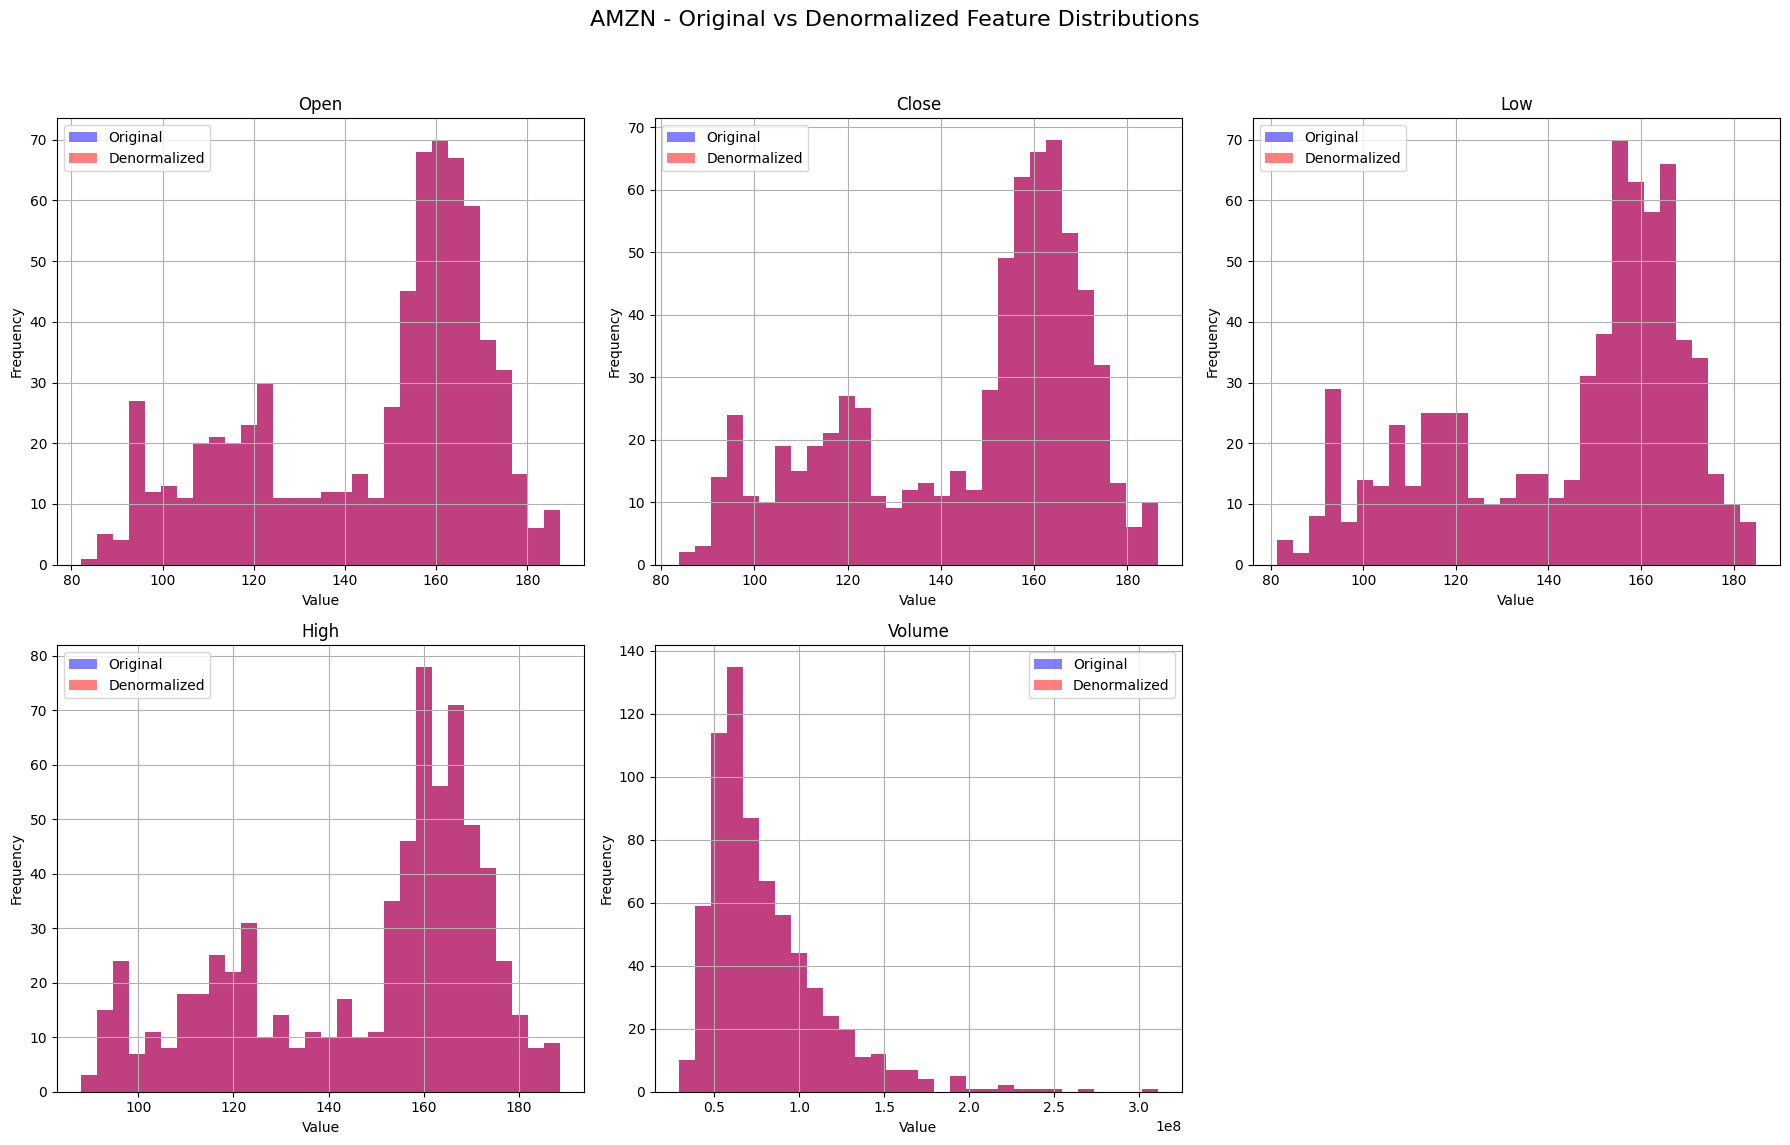

In [ ]:
def plot_denormalized_distributions(normalized_data, data, ticker, features, config, figsize=(18, 12)):
    """
    Plot original vs. denormalized feature distributions.
    
    Args:
        normalized_data: Normalized data dictionary returned by `normalize_data`.
        data: Original DataFrame containing all features.
        ticker: Ticker symbol to filter the data.
        features: List of feature names (OHLC and volume) to compare.
        config: Configuration dictionary with normalization parameters.
        figsize: Tuple defining figure size.
    """
    # Extract normalized data for the given ticker
    ticker_data = normalized_data[ticker]
    norm_ohlc = ticker_data['norm_ohlc']
    norm_volume = ticker_data['norm_volume']
    norm_params = ticker_data['norm_params']

    # Denormalize the normalized OHLC and volume data
    denorm_ohlc, denorm_volume = denormalize_data(norm_ohlc, norm_volume, norm_params)
    
    # Combine denormalized OHLC and volume for plotting
    denorm_features = np.hstack([denorm_ohlc, denorm_volume])
    denorm_features_df = pd.DataFrame(denorm_features, columns=features)

    original_data = data[data['ticker'] == ticker][features]

    # Plot distributions
    num_features = len(features)
    num_rows = (num_features + 2) // 3

    fig, axs = plt.subplots(num_rows, 3, figsize=figsize)
    fig.suptitle(f"{ticker} - Original vs Denormalized Feature Distributions", fontsize=16)
    
    axs = axs.flatten()
    for idx, feature in enumerate(features):
        ax = axs[idx]

        # Plot original feature distribution
        ax.hist(original_data[feature], bins=30, alpha=0.5, label='Original', color='blue')

        # Plot denormalized feature distribution
        ax.hist(denorm_features_df[feature], bins=30, alpha=0.5, label='Denormalized', color='red')

        ax.set_title(feature.capitalize())
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(True)

    for idx in range(len(features), len(axs)):
        fig.delaxes(axs[idx])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

ticker = "AMZN"
features = config["features"]
plot_denormalized_distributions(normalized_data=normalized_train, data=train_data, ticker=ticker, features=features, config=config)



### GAN

A GAN (Generative Adversarial Network) is made of two models:

- A generator, which creates fake data

- A discriminator, which tries to tell real from fake

The generator tries to fool the discriminator, and the discriminator tries to get better at catching fakes. Over time, the generator gets better at creating realistic-looking sequences.

### Training

In [18]:
load_pretrained = config['training_params'].get('load_pretrained', False)
logger.info(f"Checking 'load_pretrained': {load_pretrained}")

device, local_rank, world_size = setup_distributed()

generator, discriminator = None, None

if load_pretrained:
    logger.info("Attempting to load pretrained model...")
    checkpoint_path = checkpoint_dir / "model_best.pth.tar"
    print(checkpoint_path)
    if checkpoint_path.exists():
        try:
            generator, discriminator = create_models(input_size, output_size, config, device)
            generator, _, _, _ = load_checkpoint(
                str(checkpoint_path),
                generator,
                discriminator
            )
            generator = generator.to(device)
            logger.info("Successfully loaded pretrained model.")
        except (FileNotFoundError, RuntimeError, OSError) as e:
            logger.warning(f"Failed to load pretrained model: {e}. Proceeding to train a new model.")
    else:
        logger.warning(f"No pretrained model found at {checkpoint_path}. Proceeding to train a new model.")


2025-07-02 17:54:23,567 - __main__ - INFO - Checking 'load_pretrained': False


In [19]:
unique_tickers = sorted(data['ticker'].unique())
ticker_to_idx = {t: i for i, t in enumerate(unique_tickers)}

In [20]:
# Only train if loading fails
if generator is None or discriminator is None:
    logger.info("Initializing and training new models...")
    generator, device = train_gan(
        train_data=train_data,
        validation_data=val_data,
        sequence_length=config['sequence_length'],
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        checkpoint_dir=checkpoint_dir,
        patience=config['patience'],
        config=config,
        input_size=input_size,
        output_size=output_size,
        ticker_to_idx=ticker_to_idx
    )

2025-07-02 17:54:23,584 - __main__ - INFO - Initializing and training new models...
2025-07-02 17:54:23,586 - src.training.train - INFO - Training on device: cpu, local_rank: 0, world_size: 1
2025-07-02 17:54:33,398 - src.training.train - INFO - Epoch 1: Generator LR: 0.000200
2025-07-02 17:54:33,400 - src.training.train - INFO - Epoch 1: Discriminator LR: 0.000200
2025-07-02 17:54:33,401 - src.training.train - INFO - Validation Loss: 0.551519
2025-07-02 17:54:33,402 - src.training.train - INFO - 
Epoch 1 / 100
2025-07-02 17:54:33,403 - src.training.train - INFO - Generator Loss: 0.6486
2025-07-02 17:54:33,404 - src.training.train - INFO - Discriminator Loss: 0.6990
2025-07-02 17:54:33,405 - src.training.train - INFO - Validation Loss: 0.5515
2025-07-02 17:54:33,406 - src.training.train - INFO - Generator LR: 0.000200
2025-07-02 17:54:33,407 - src.training.train - INFO - Discriminator LR: 0.000200
2025-07-02 17:54:42,804 - src.training.train - INFO - Epoch 2: Generator LR: 0.000400
202

2025-07-03 18:20:29,402 - __main__ - INFO - 
Processing AAPL...


2025-07-03 18:20:29,535 - src.evaluation.metrics - INFO - 
Evaluation Metrics for AAPL:
2025-07-03 18:20:29,543 - src.evaluation.metrics - INFO - Feature: open
2025-07-03 18:20:29,543 - src.evaluation.metrics - INFO -   MAE: 1.9159
2025-07-03 18:20:29,544 - src.evaluation.metrics - INFO -   MAPE: 1.04%
2025-07-03 18:20:29,544 - src.evaluation.metrics - INFO -   Correlation: 0.9649
2025-07-03 18:20:29,545 - src.evaluation.metrics - INFO -   KL Divergence: 2.4251
2025-07-03 18:20:29,546 - src.evaluation.metrics - INFO -   JS Divergence: 0.3181
2025-07-03 18:20:29,546 - src.evaluation.metrics - INFO -   Wasserstein Distance: 1.1563

2025-07-03 18:20:29,550 - src.evaluation.metrics - INFO - Feature: close
2025-07-03 18:20:29,551 - src.evaluation.metrics - INFO -   MAE: 2.3027
2025-07-03 18:20:29,552 - src.evaluation.metrics - INFO -   MAPE: 1.27%
2025-07-03 18:20:29,552 - src.evaluation.metrics - INFO -   Correlation: 0.9302
2025-07-03 18:20:29,553 - src.evaluation.metrics - INFO -   KL Di

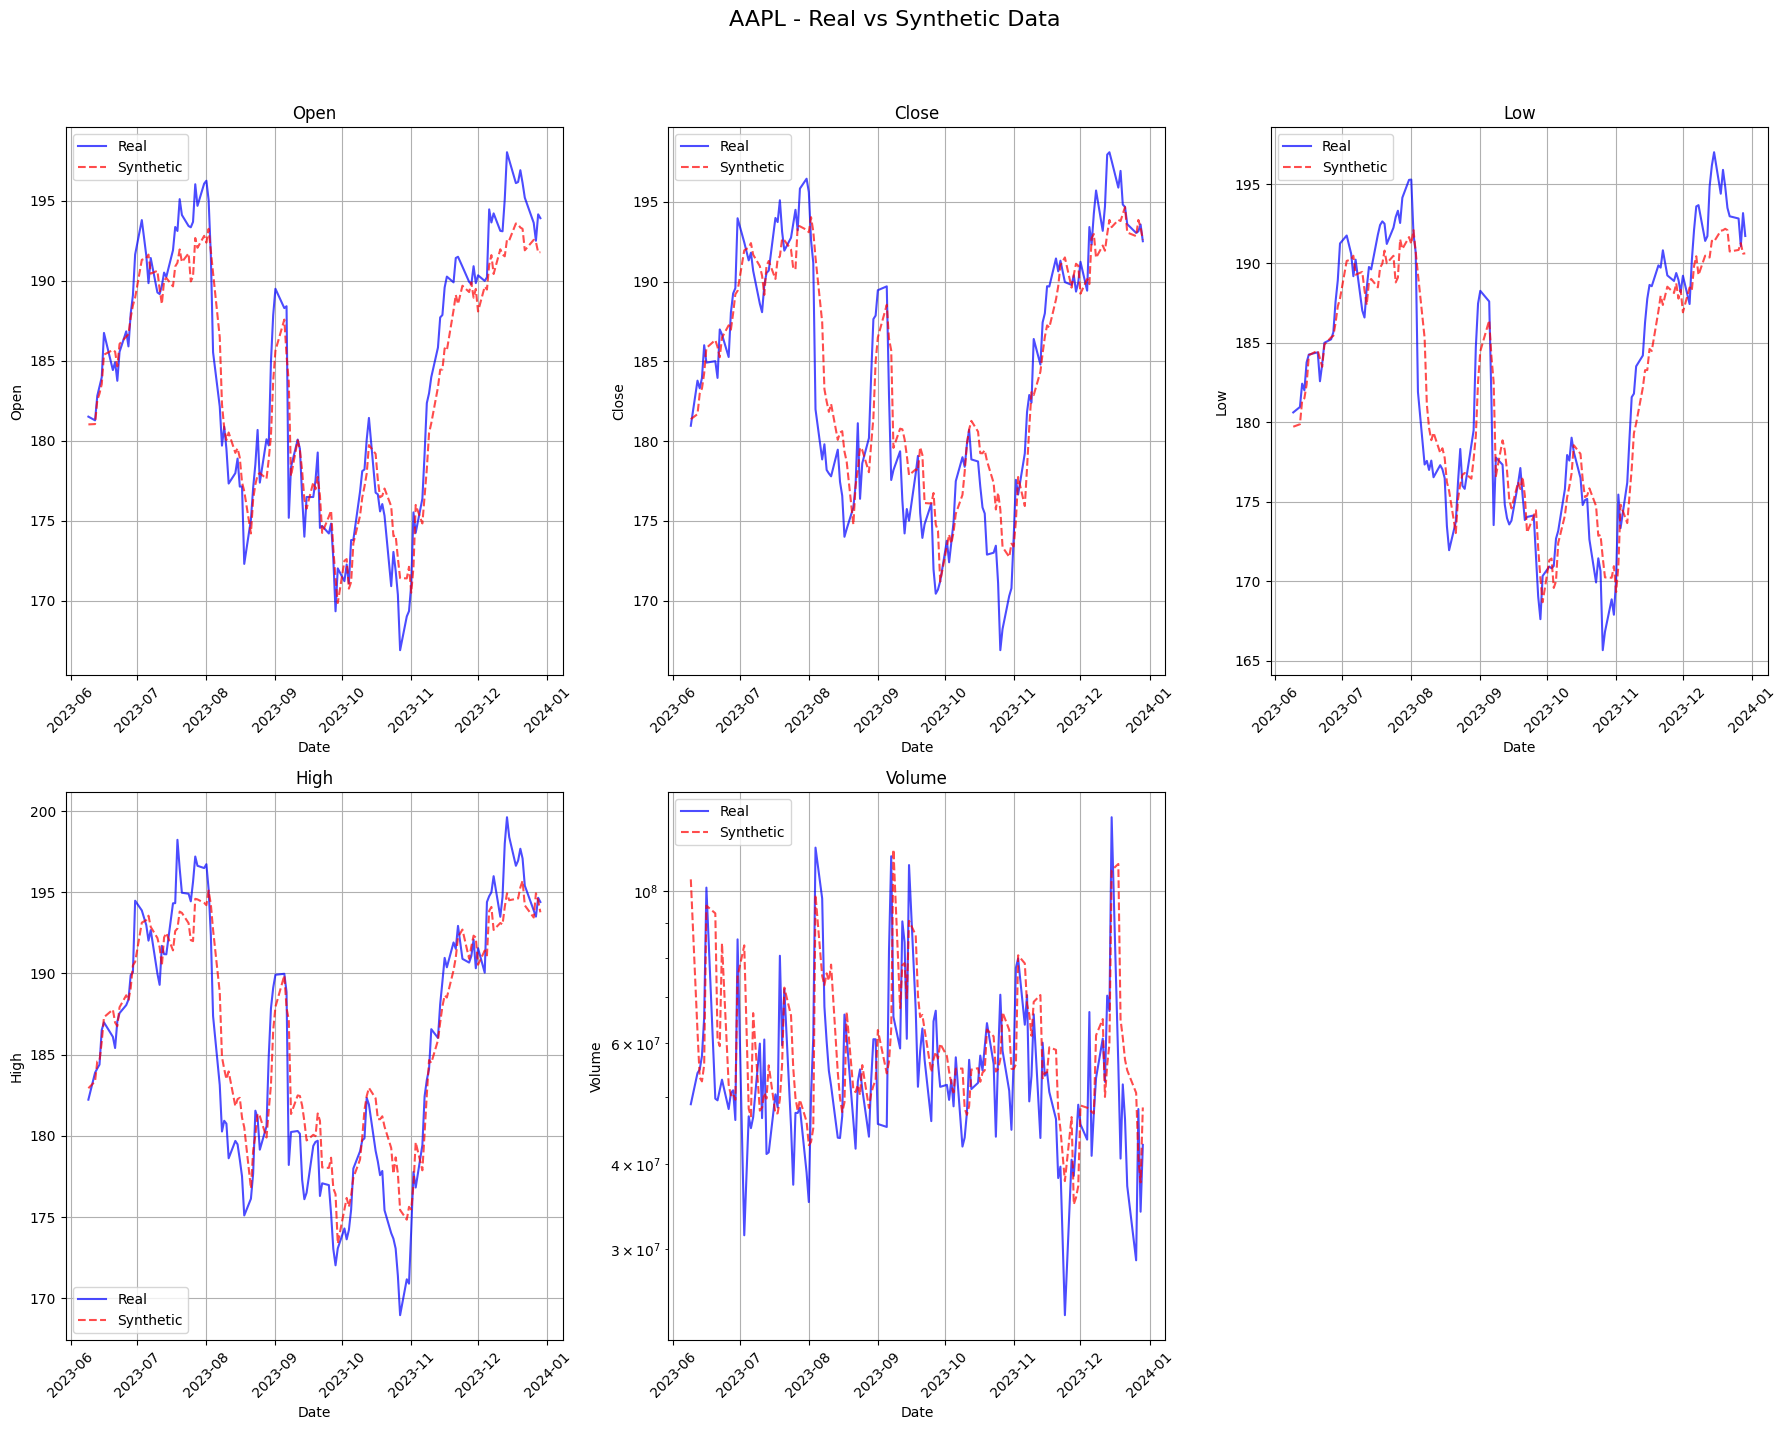

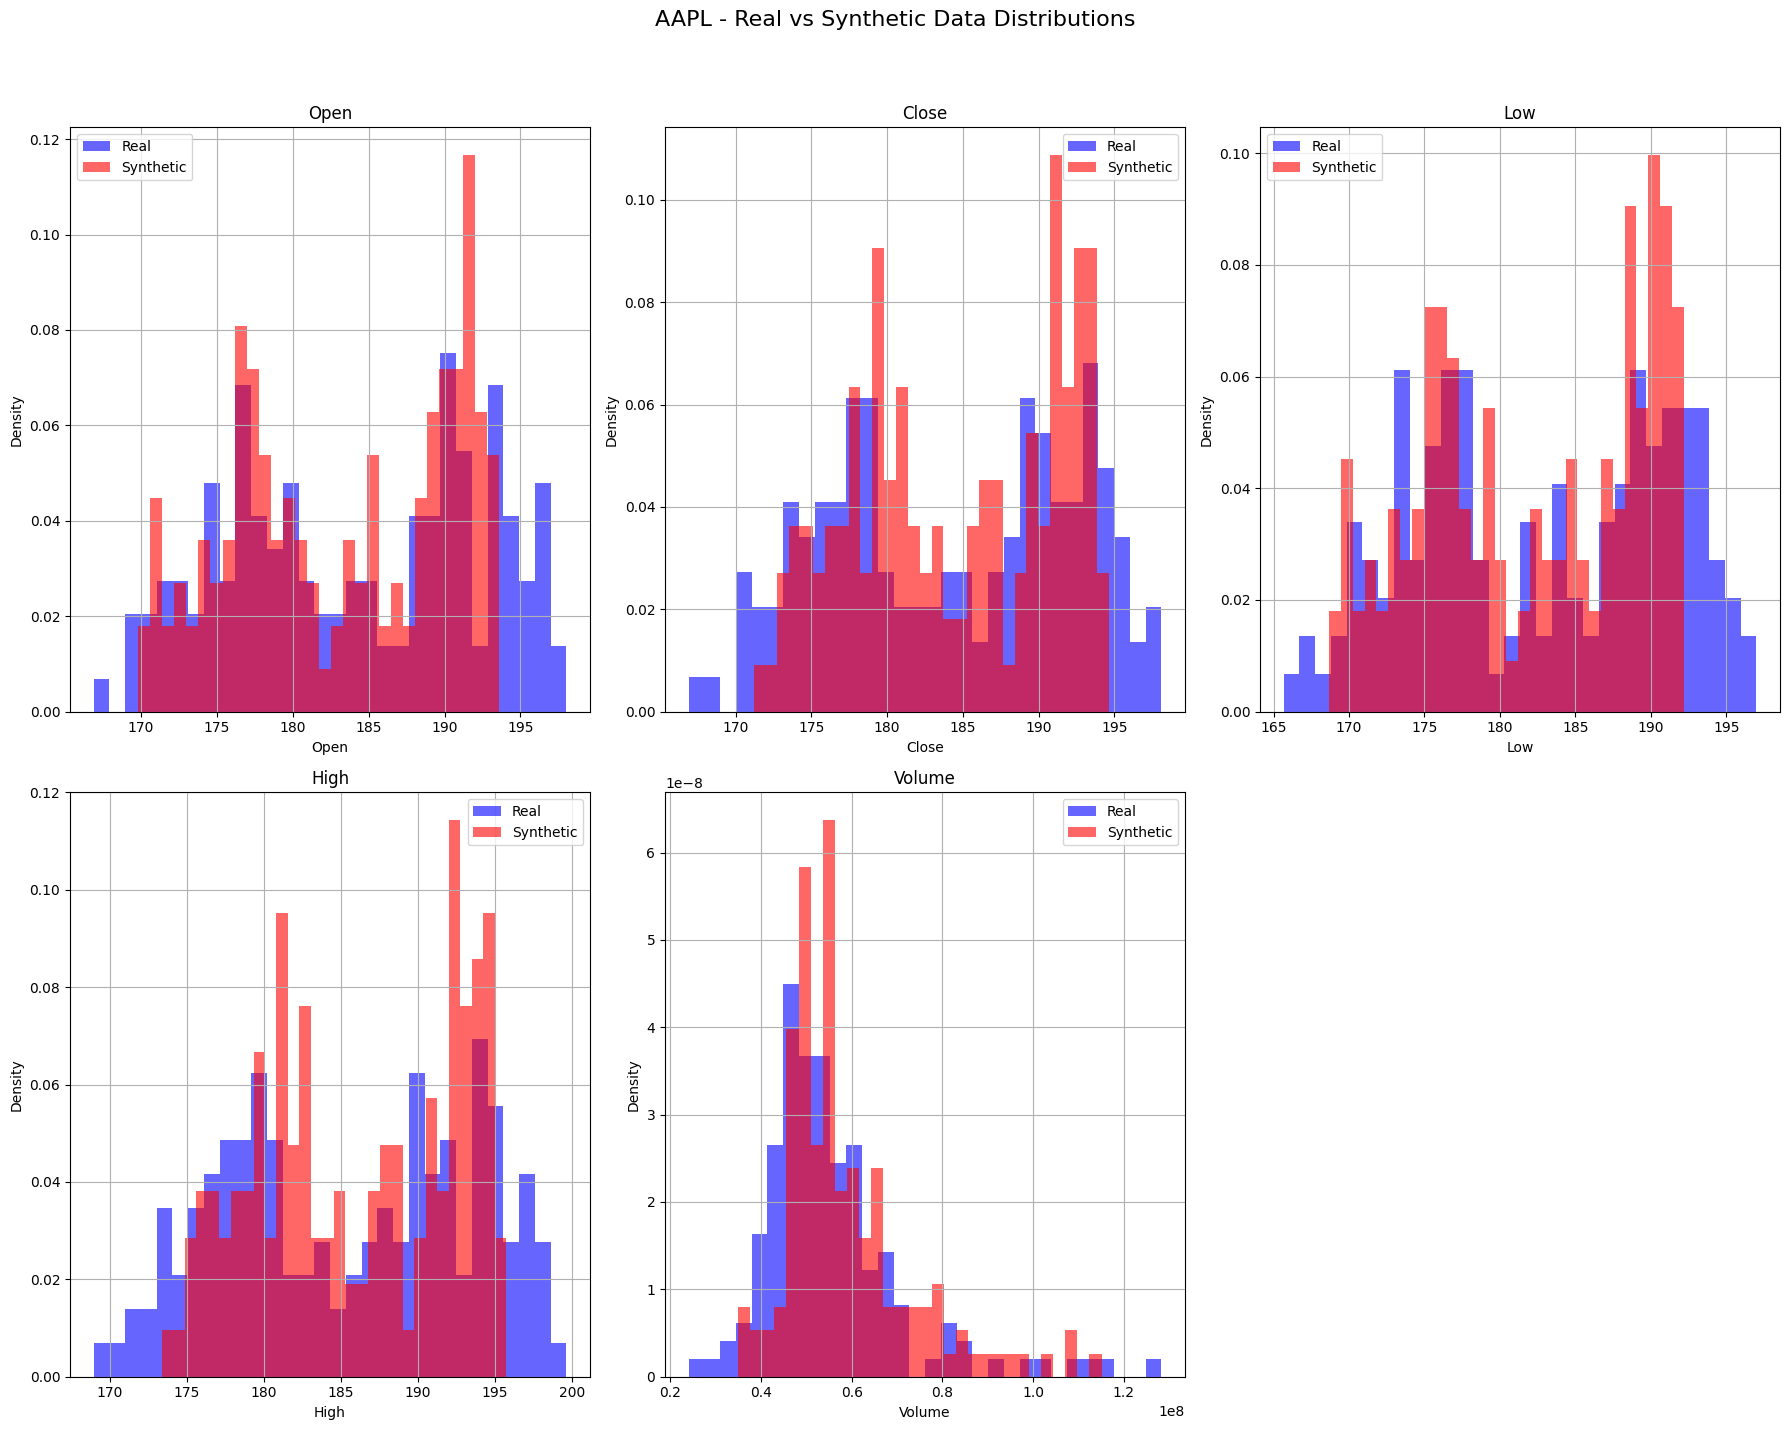

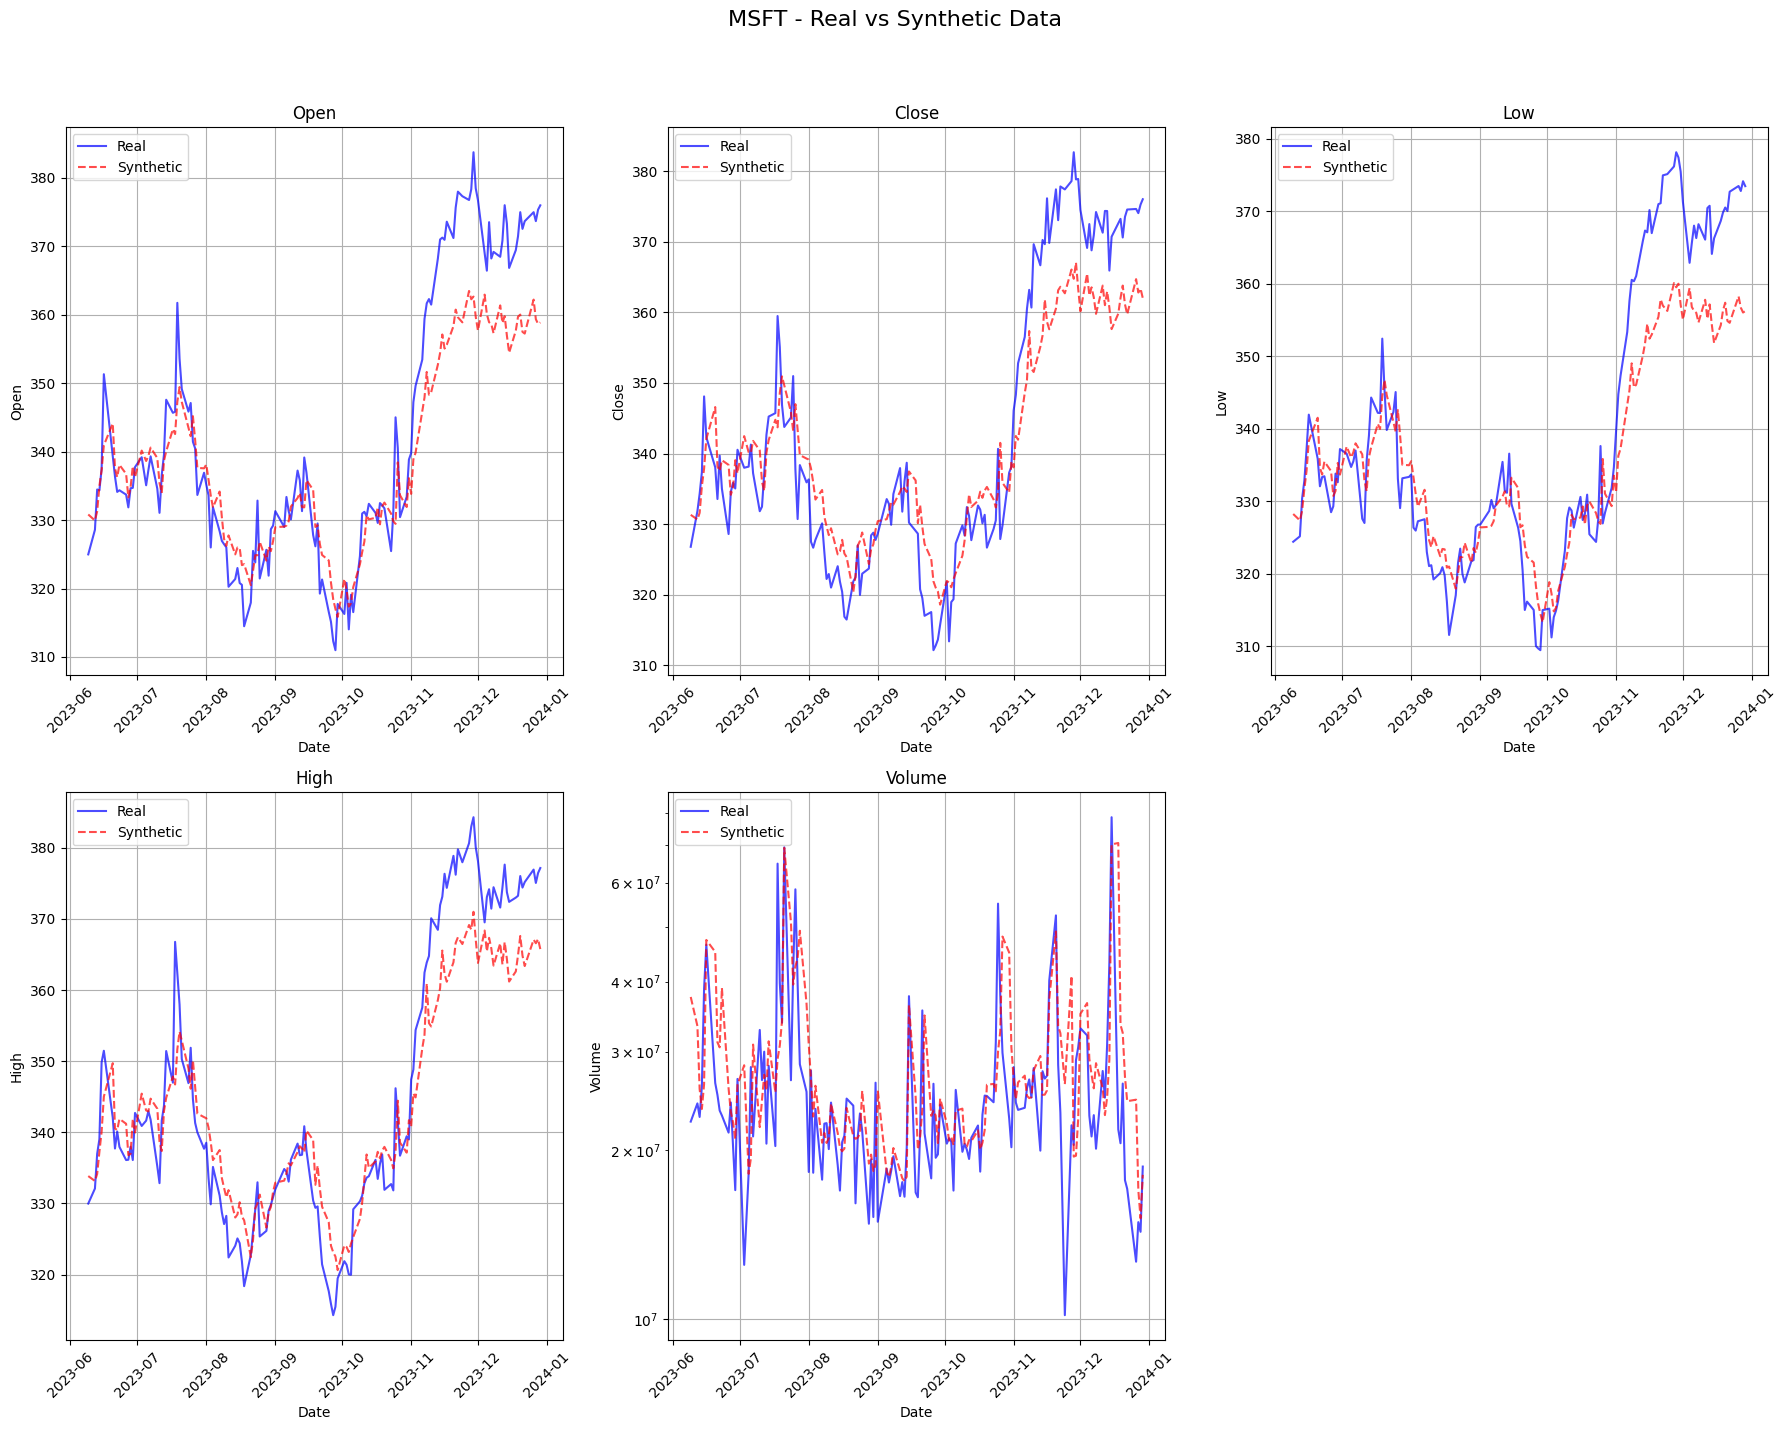

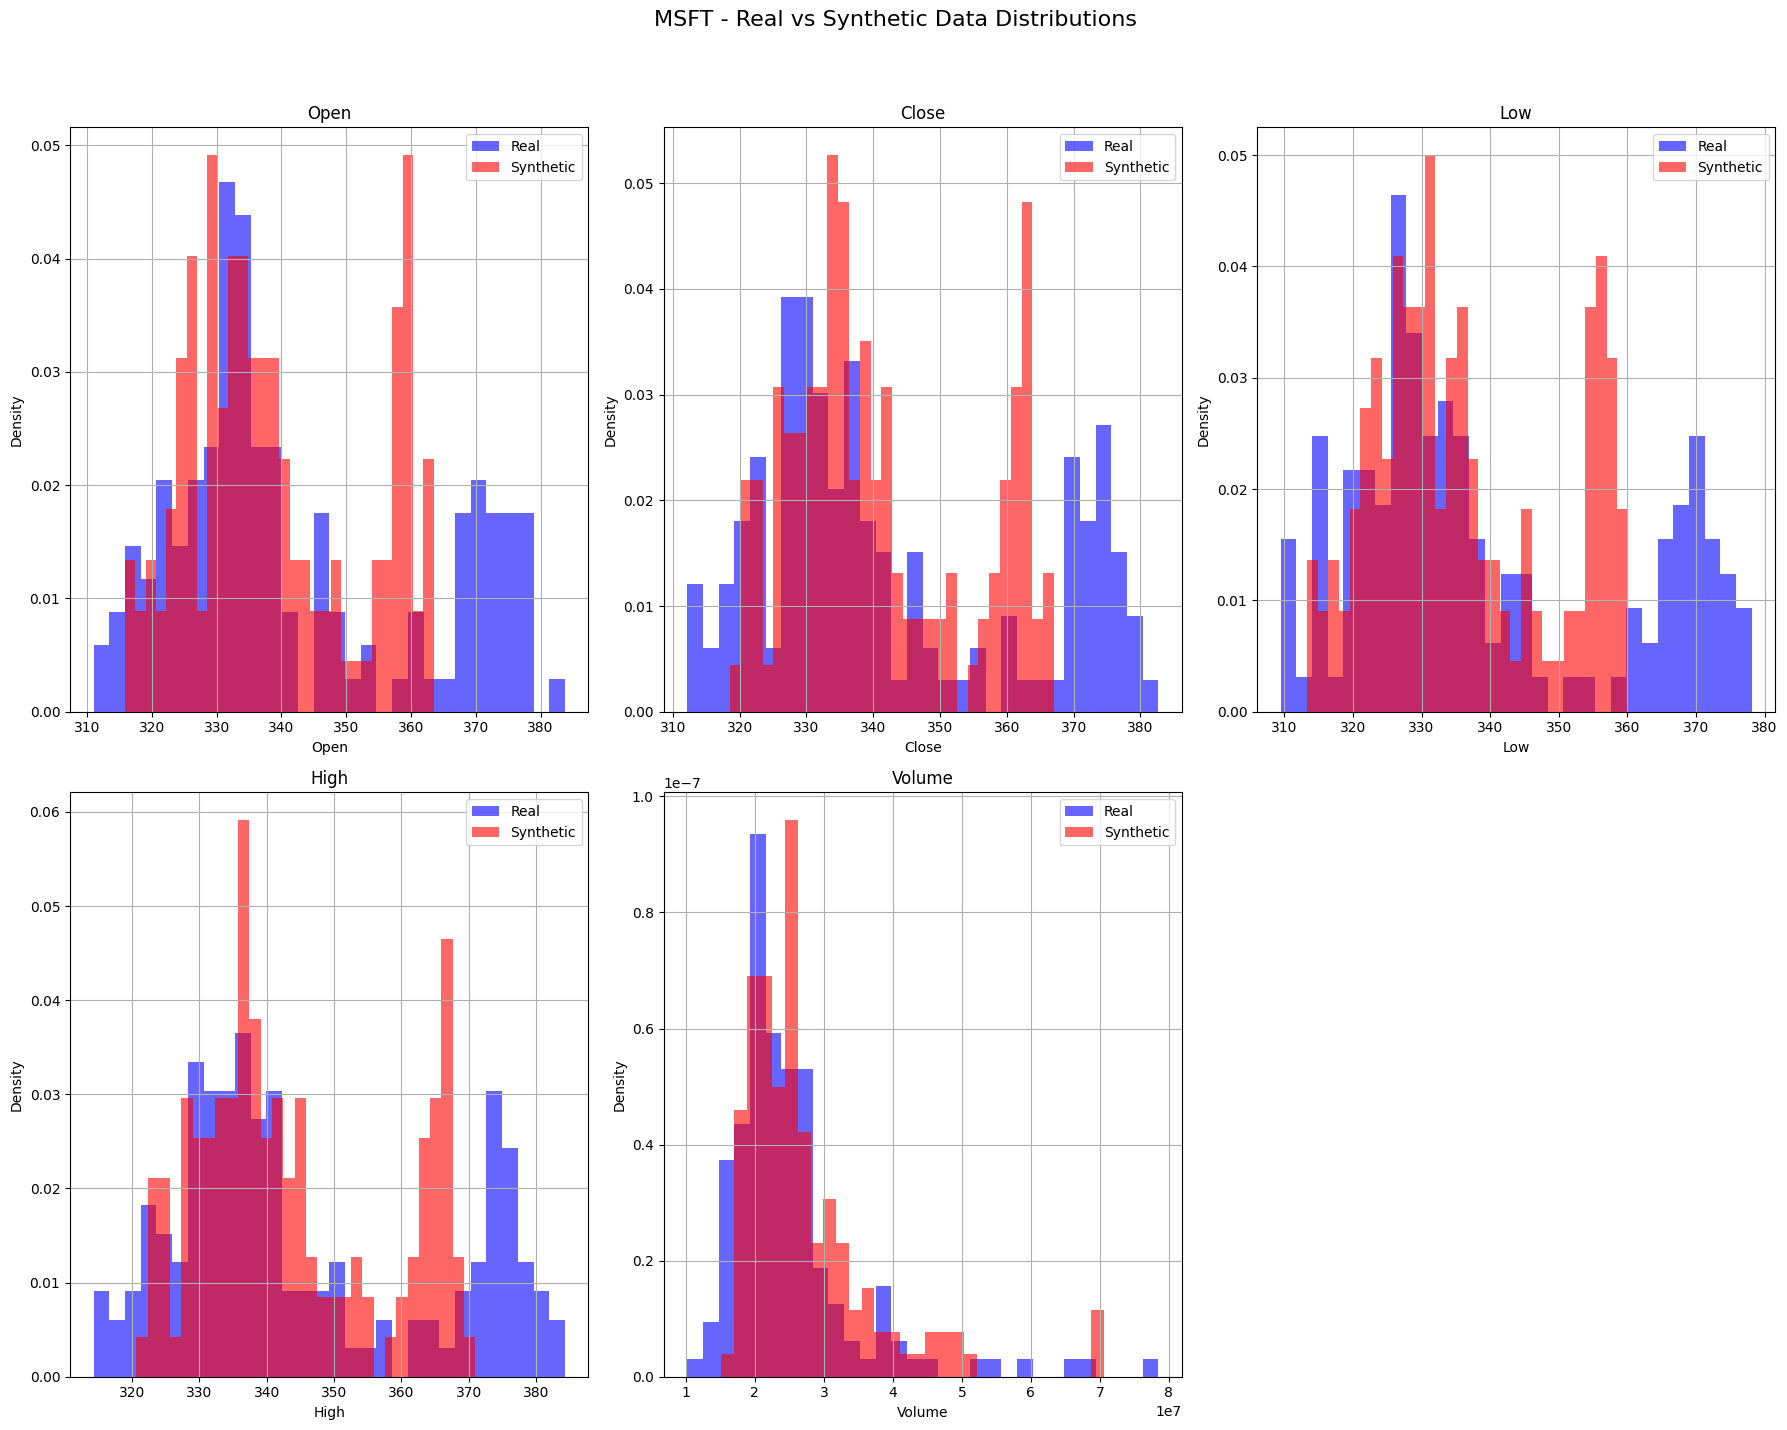

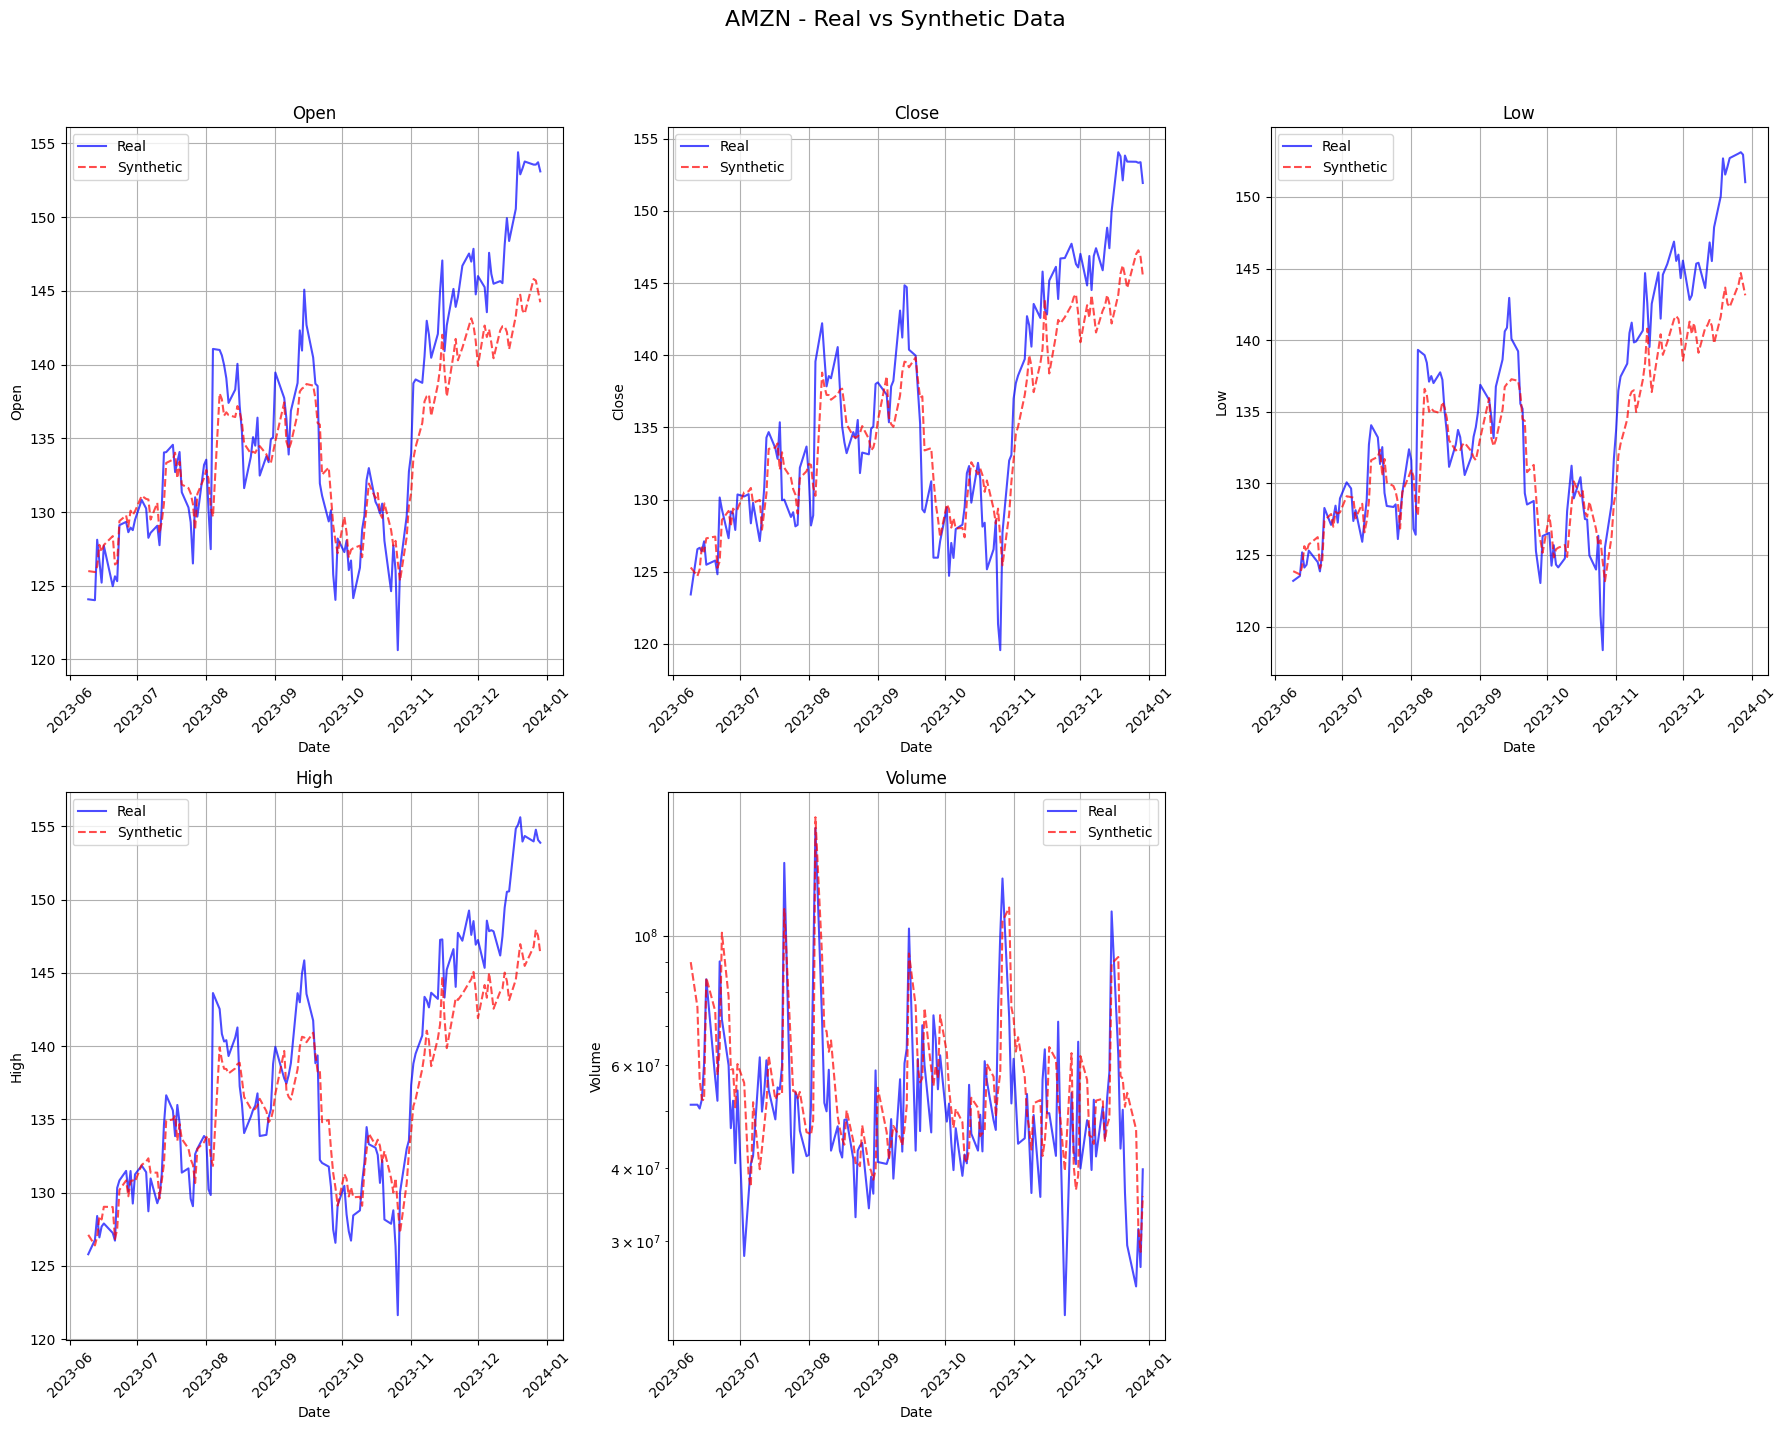

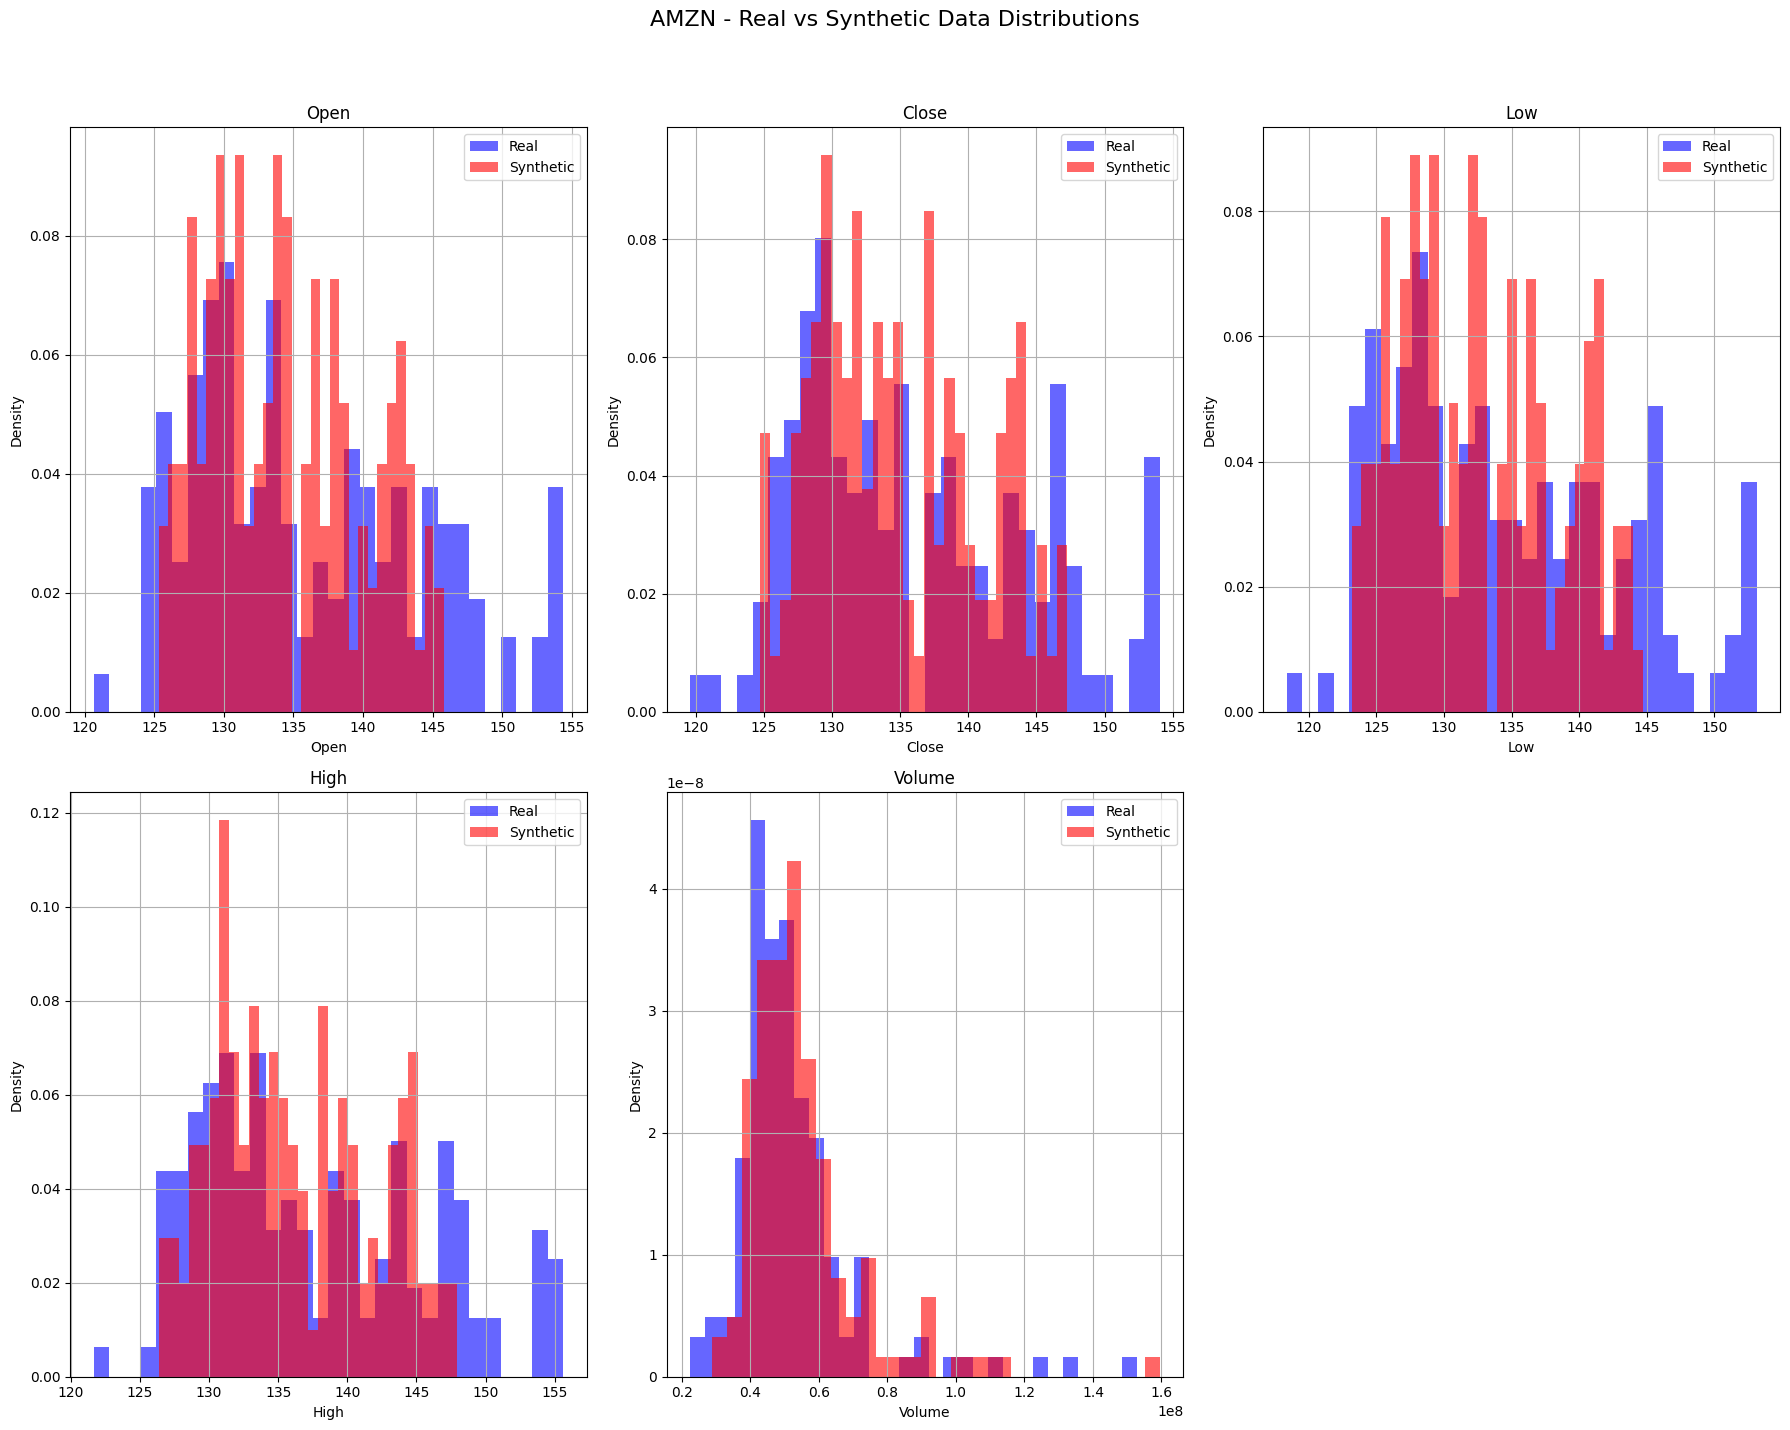

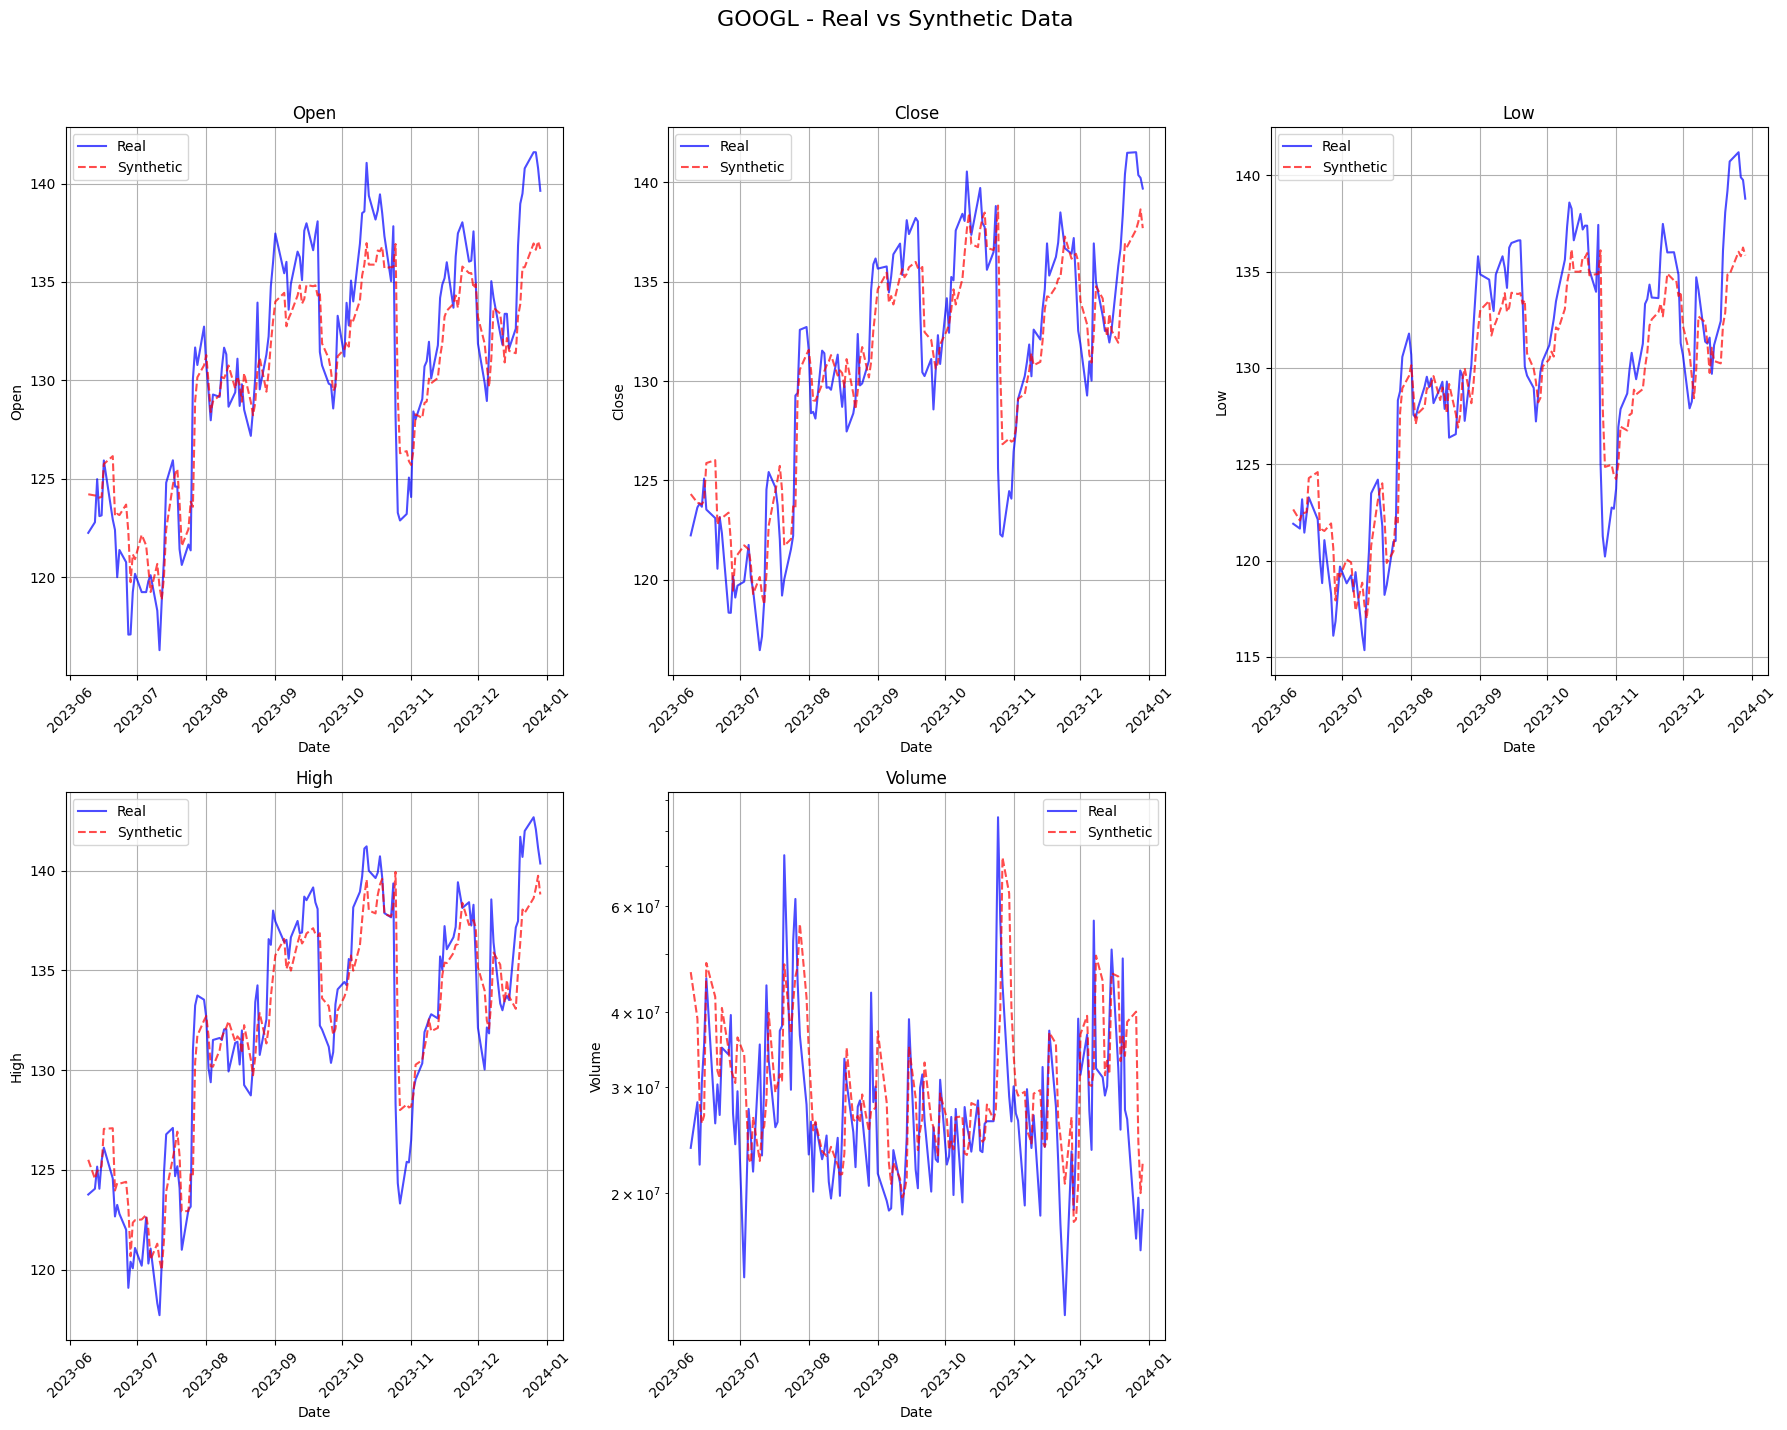

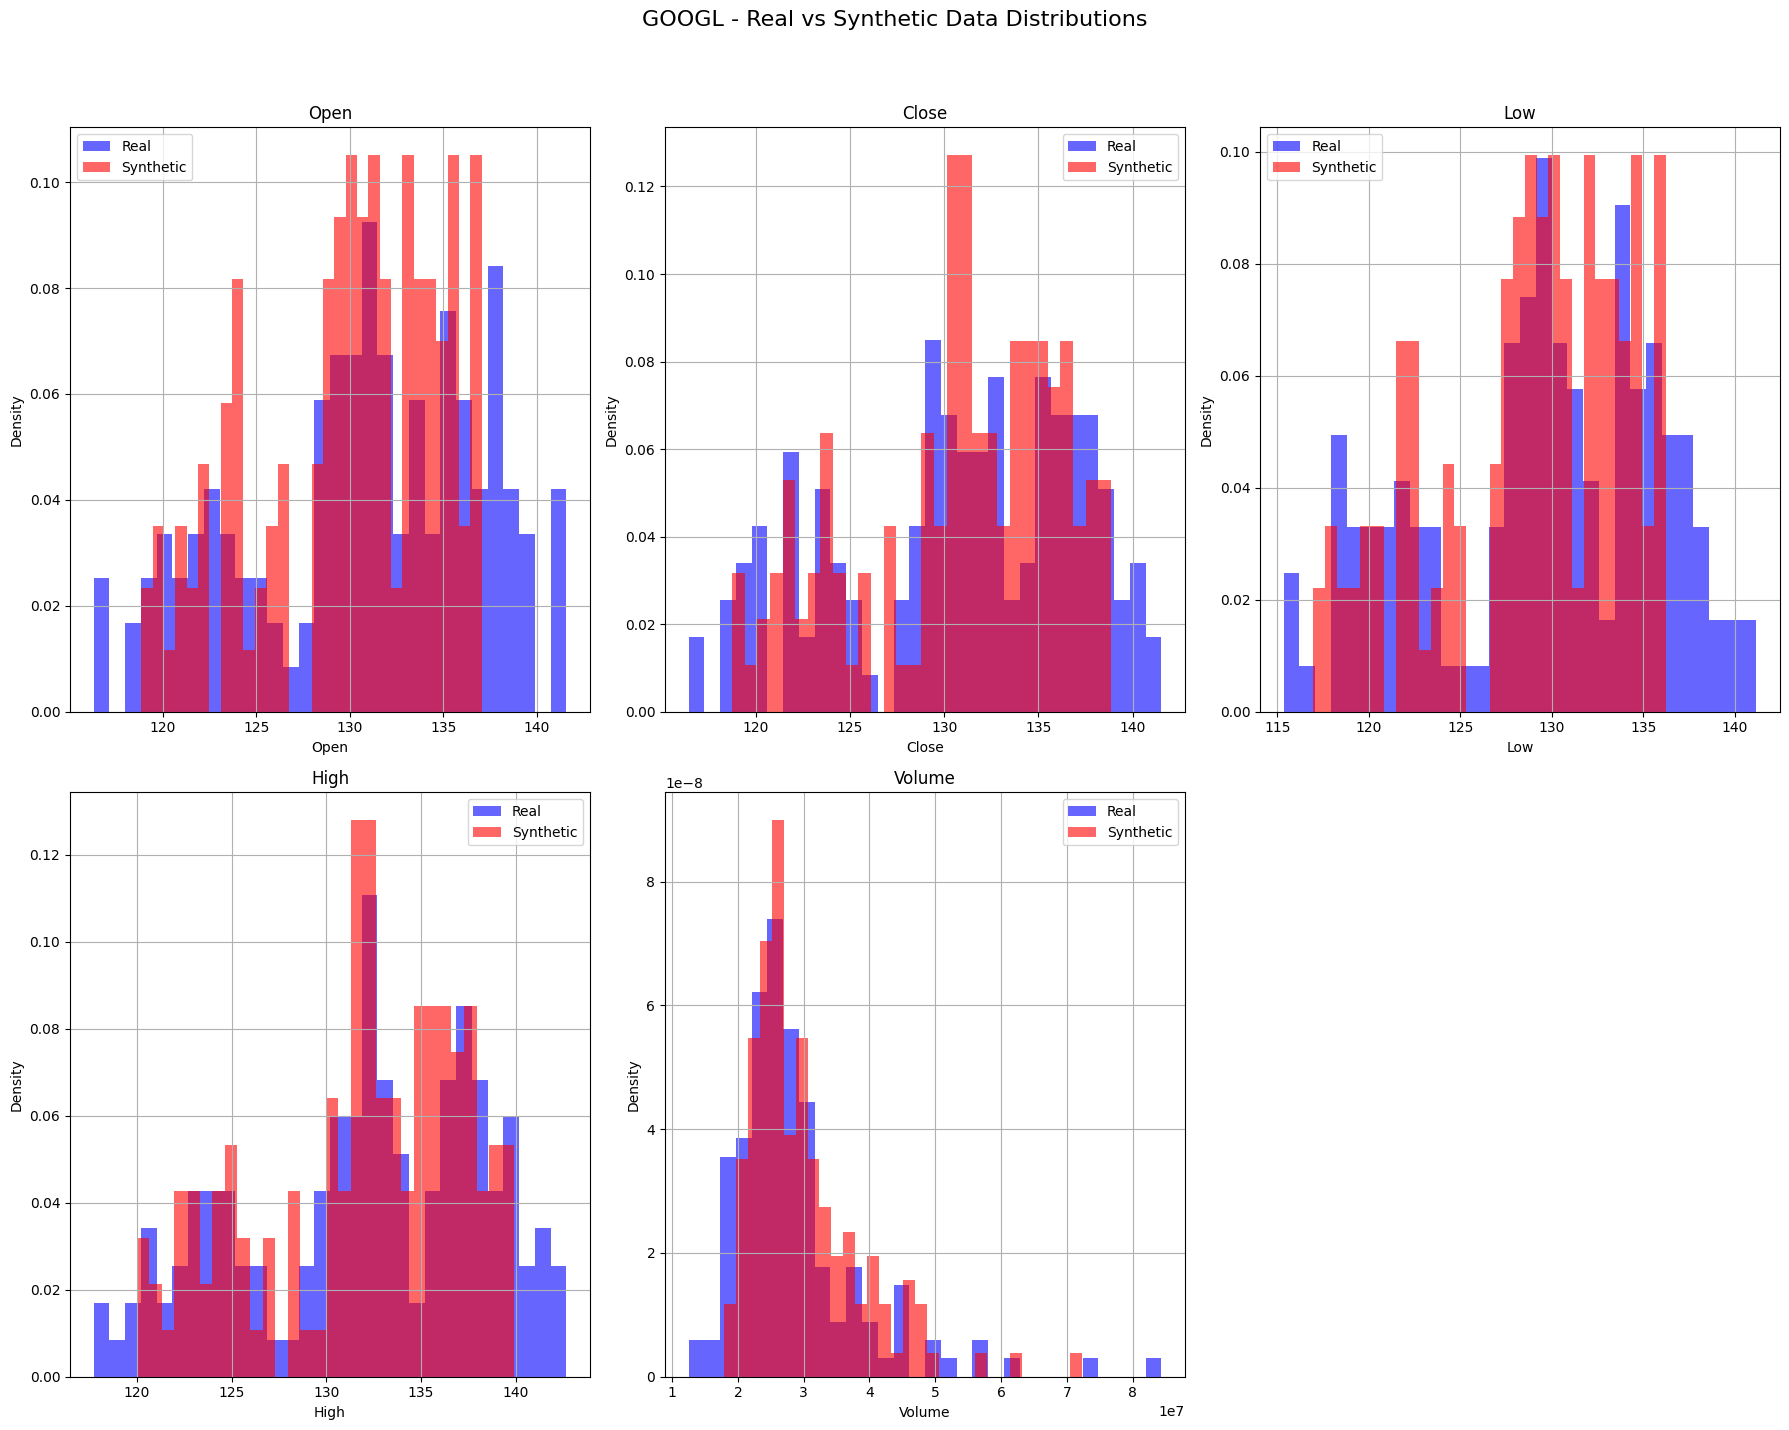

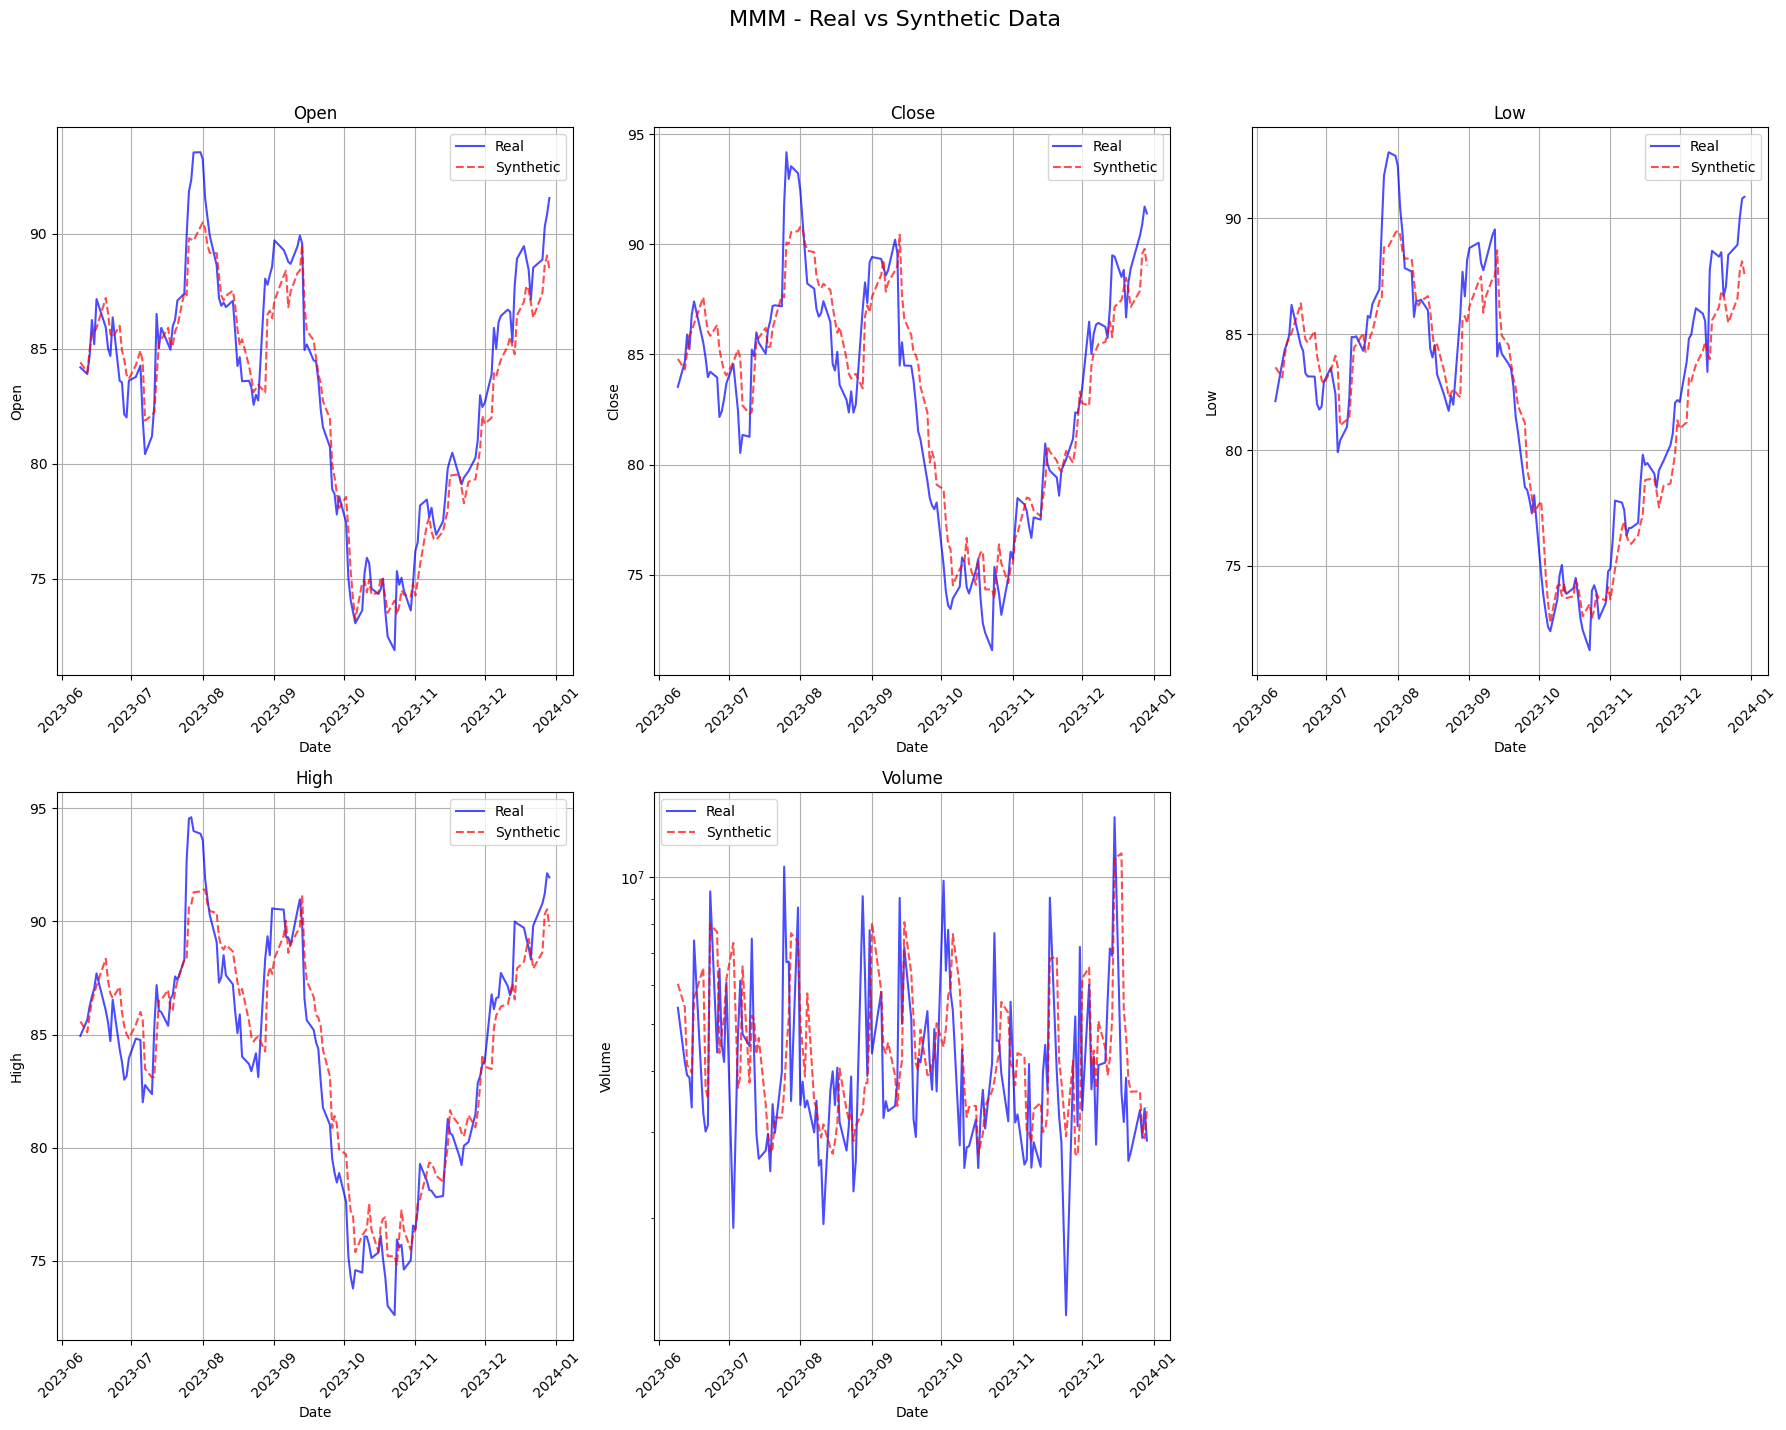

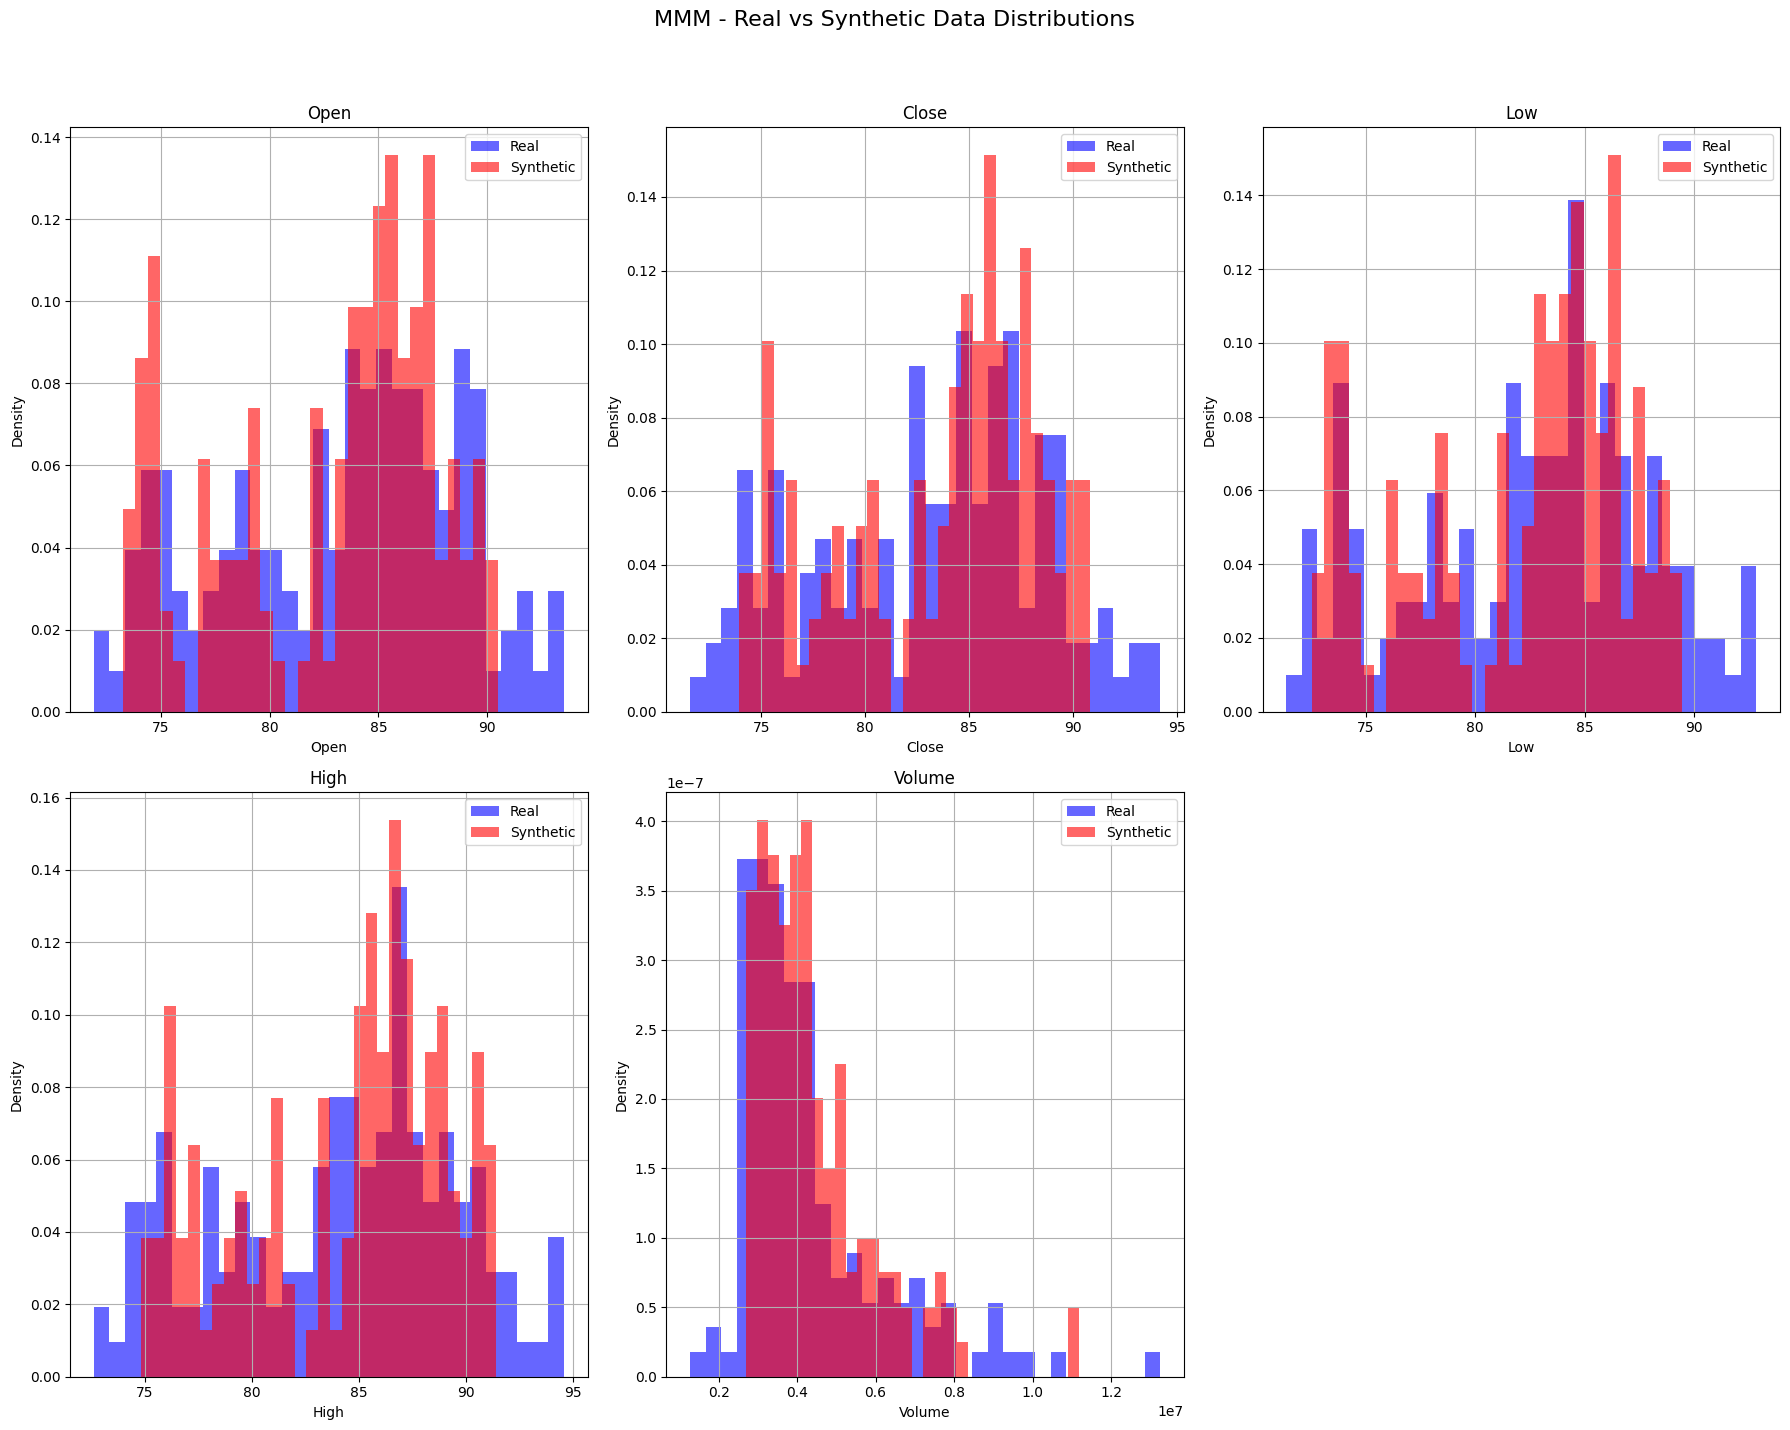

In [ ]:
# Generate and evaluate data
results = {}

for ticker in config['tickers']:
    logger.info(f"\nProcessing {ticker}...")
    df_ticker = test_data[test_data['ticker'] == ticker].reset_index(drop=True)

    if len(df_ticker) <= config['sequence_length']:
        logger.warning(f"Insufficient test data for ticker {ticker}. Skipping evaluation.")
        continue

    # Generate synthetic data
    y_pred, dates = generate_synthetic_data(
        generator=generator,
        df_ticker=df_ticker,
        sequence_length=config['sequence_length'],
        device=device,
        cyclic_config=config['data_params']['cyclic_features'],
        ticker_to_idx=ticker_to_idx
    )

    # Extract actual features (OHLC + volume)
    n_features = len(config['features'])
    y_pred = y_pred[:, :n_features]

    y_true = df_ticker[config['features']].iloc[config['sequence_length']:].values

    # Get training data and normalize it
    tickers = test_data['ticker'].unique()
    normalized_train = normalize_data(train_data, tickers, config['data_params']['cyclic_features'])
    train_sequences, train_targets = create_sequences(normalized_train, config['sequence_length'])
    
    # Get normalization parameters for denormalization
    norm_params = normalized_train[ticker]['norm_params']
    
    # Denormalize training targets to match y_pred scale
    train_targets_normalized = train_targets[ticker][:, :n_features]  # Get normalized training targets
    
    # Create volume array for denormalization (we only need OHLC + volume)
    train_ohlc_normalized = train_targets_normalized[:, :4]  # OHLC
    train_volume_normalized = train_targets_normalized[:, 4:5]  # Volume
    
    # Denormalize both OHLC and volume
    train_ohlc_denorm, train_volume_denorm = denormalize_data(
        train_ohlc_normalized, 
        train_volume_normalized, 
        norm_params
    )
    
    # Combine denormalized OHLC and volume
    train_targets_denormalized = np.hstack([train_ohlc_denorm, train_volume_denorm])
    
    # Use denormalized training targets
    metrics = evaluate_generated_data(
        y_true=y_true,
        y_pred=y_pred,
        features=config['features'],
        ticker=ticker,
        cyclic_config=config['data_params']['cyclic_features']
    )

    # Visualizations
    plot_comparisons_grid(
        y_true,
        y_pred,
        dates,
        config['features'],
        ticker,
        save_path=str(output_dir / f"{ticker}_comparisons.png")
    )

    plot_distributions(
        y_true=y_true,
        y_pred=y_pred,
        features=config['features'],
        ticker=ticker,
        save_path=output_dir / f"{ticker}_distributions.png"
    )

    pca_tsne_visualization(
        y_true,
        y_pred,
        ticker,
        save_dir=str(output_dir),
        random_state=config['seed']
    )

    results[ticker] = metrics

# Save metrics
metrics_path = output_dir / "metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(results, f, indent=4)
logger.info(f"Saved evaluation metrics to {metrics_path}")

logger.info("Training and Evaluation Complete")

# Results

In [22]:
with open('outputs/metrics.json', 'r') as f:
    metrics = json.load(f)

In [23]:
def create_summary_table(metrics):
    summary_data = []
    
    for ticker, features in metrics.items():
        for feature, metric_values in features.items():
            summary_data.append({
                'Stock': ticker,
                'Feature': feature,
                'MAE': f"{metric_values.get('mae', 0):.2f}",
                'MAPE': f"{metric_values.get('mape', 0):.2f}%",
                'Correlation': f"{metric_values.get('correlation', 0):.3f}",
                'KL Divergence': f"{metric_values.get('kl_divergence', 0):.2f}",
                'JS Divergence': f"{metric_values.get('js_divergence', 0):.2f}",
                'Wasserstein': f"{metric_values.get('wasserstein_distance', 0):.2f}"
            })
    
    return pd.DataFrame(summary_data)

summary_df = create_summary_table(metrics)
display(summary_df)

summary_df.to_csv('metrics_summary.csv', index=False)

,Stock,Feature,MAE,MAPE,Correlation,KL Divergence,JS Divergence,Wasserstein
0,AAPL,open,1.91,1.03%,0.966,2.15,0.33,1.19
1,AAPL,close,2.30,1.26%,0.931,0.90,0.28,1.36
2,AAPL,low,2.12,1.16%,0.950,1.56,0.27,1.21
3,AAPL,high,2.13,1.16%,0.955,1.77,0.33,1.53
4,AAPL,volume,10467034.53,19.83%,0.516,0.41,0.30,3955841.94
5,MSFT,open,6.39,1.80%,0.950,1.79,0.35,4.94
6,MSFT,close,6.52,1.86%,0.931,1.68,0.34,5.37
7,MSFT,low,6.51,1.85%,0.939,1.90,0.32,5.03
8,MSFT,high,5.63,1.59%,0.957,1.21,0.27,4.63
9,MSFT,volume,5634714.01,23.69%,0.588,0.42,0.30,2315800.23


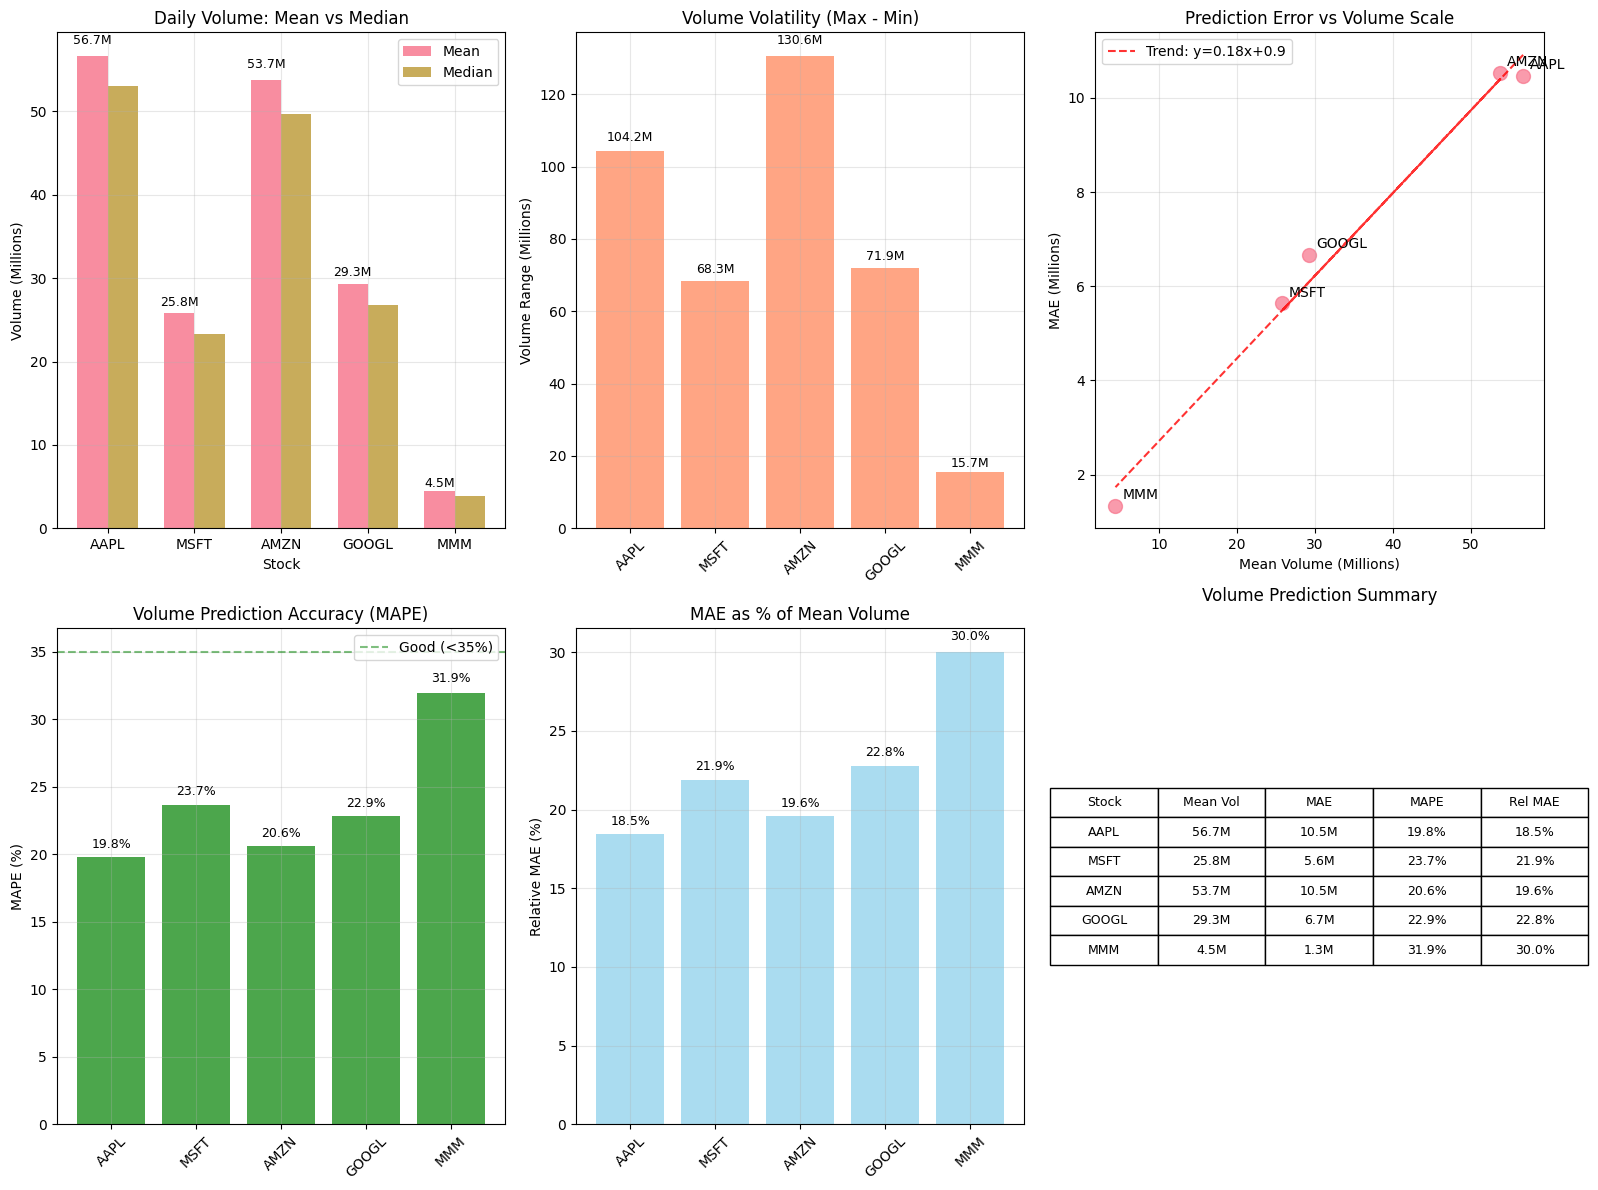


📊 Volume Analysis Summary:
AAPL: Mean=56.7M, MAE=10.5M (18.5% relative)
MSFT: Mean=25.8M, MAE=5.6M (21.9% relative)
AMZN: Mean=53.7M, MAE=10.5M (19.6% relative)
GOOGL: Mean=29.3M, MAE=6.7M (22.8% relative)
MMM: Mean=4.5M, MAE=1.3M (30.0% relative)

🔍 Key Insights:
Highest volume: AAPL (56.7M)
Lowest volume:  MMM (4.5M)
Best MAPE:      AAPL (19.8%)
Worst MAPE:     MMM (31.9%)


In [ ]:
def create_volume_analysis_plots(test_data, metrics_df):
    """
    Create comprehensive volume analysis visualizations using actual data
    
    Args:
        test_data: Test dataset DataFrame
        metrics_df: Metrics DataFrame from the evaluation
    """

    volume_stats = {}
    mae_results = {}
    mape_results = {}
    
    tickers = test_data['ticker'].unique()
    
    for ticker in tickers:
        ticker_data = test_data[test_data['ticker'] == ticker]
        volume_stats[ticker] = {
            'mean': ticker_data['volume'].mean(),
            'median': ticker_data['volume'].median(),
            'min': ticker_data['volume'].min(),
            'max': ticker_data['volume'].max(),
            'std': ticker_data['volume'].std()
        }

        ticker_metrics = metrics_df[metrics_df['Stock'] == ticker]
        volume_row = ticker_metrics[ticker_metrics['Feature'] == 'volume']
        
        if not volume_row.empty:
            mae_results[ticker] = float(volume_row['MAE'].iloc[0])
            mape_results[ticker] = float(volume_row['MAPE'].str.rstrip('%').iloc[0])
    
    plt.style.use('default')
    sns.set_palette("husl")

    fig = plt.figure(figsize=(16, 12))
    
    # 1. Volume Statistics Comparison
    ax1 = plt.subplot(2, 3, 1)
    means = [volume_stats[t]['mean'] for t in tickers]
    medians = [volume_stats[t]['median'] for t in tickers]
    
    x = np.arange(len(tickers))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, np.array(means)/1e6, width, label='Mean', alpha=0.8)
    bars2 = ax1.bar(x + width/2, np.array(medians)/1e6, width, label='Median', alpha=0.8)
    
    ax1.set_xlabel('Stock')
    ax1.set_ylabel('Volume (Millions)')
    ax1.set_title('Daily Volume: Mean vs Median')
    ax1.set_xticks(x)
    ax1.set_xticklabels(tickers)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                f'{height:.1f}M', ha='center', va='bottom', fontsize=9)
    
    # 2. Volume Range (Min-Max)
    ax2 = plt.subplot(2, 3, 2)
    mins = [volume_stats[t]['min'] for t in tickers]
    maxs = [volume_stats[t]['max'] for t in tickers]
    ranges = [maxs[i] - mins[i] for i in range(len(tickers))]
    
    bars = ax2.bar(tickers, np.array(ranges)/1e6, alpha=0.7, color='coral')
    ax2.set_ylabel('Volume Range (Millions)')
    ax2.set_title('Volume Volatility (Max - Min)')
    ax2.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Add value labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                f'{height:.1f}M', ha='center', va='bottom', fontsize=9)
    
    # 3. MAE vs Mean Volume Relationship
    ax3 = plt.subplot(2, 3, 3)
    mean_vols = [volume_stats[t]['mean']/1e6 for t in tickers]
    maes = [mae_results[t]/1e6 for t in tickers]
    
    scatter = ax3.scatter(mean_vols, maes, s=100, alpha=0.7)
    for i, ticker in enumerate(tickers):
        ax3.annotate(ticker, (mean_vols[i], maes[i]), 
                    xytext=(5, 5), textcoords='offset points')
    
    ax3.set_xlabel('Mean Volume (Millions)')
    ax3.set_ylabel('MAE (Millions)')
    ax3.set_title('Prediction Error vs Volume Scale')
    ax3.grid(True, alpha=0.3)
    
    # Add trend line if we have enough data points
    if len(mean_vols) > 1:
        z = np.polyfit(mean_vols, maes, 1)
        p = np.poly1d(z)
        ax3.plot(mean_vols, p(mean_vols), "r--", alpha=0.8, 
                 label=f'Trend: y={z[0]:.2f}x+{z[1]:.1f}')
        ax3.legend()
    
    # 4. MAPE Performance Ranking
    ax4 = plt.subplot(2, 3, 4)
    mapes = [mape_results[t] for t in tickers]
    colors = ['green' if m < 35 else 'orange' if m < 45 else 'red' for m in mapes]
    
    bars = ax4.bar(tickers, mapes, color=colors, alpha=0.7)
    ax4.set_ylabel('MAPE (%)')
    ax4.set_title('Volume Prediction Accuracy (MAPE)')
    ax4.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Add value labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Add performance thresholds
    max_mape = max(mapes)
    ax4.axhline(y=35, color='green', linestyle='--', alpha=0.5, label='Good (<35%)')
    if max_mape > 35:
        ax4.axhline(y=45, color='orange', linestyle='--', alpha=0.5, label='Fair (35-45%)')
    ax4.legend()
    
    # 5. Relative Error Analysis
    ax5 = plt.subplot(2, 3, 5)
    relative_errors = [(mae_results[t]/volume_stats[t]['mean'])*100 for t in tickers]
    
    bars = ax5.bar(tickers, relative_errors, alpha=0.7, color='skyblue')
    ax5.set_ylabel('Relative MAE (%)')
    ax5.set_title('MAE as % of Mean Volume')
    ax5.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # 6. Summary Statistics Table
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('tight')
    ax6.axis('off')
    
    # Create summary data
    summary_data = []
    for ticker in tickers:
        summary_data.append([
            ticker,
            f"{volume_stats[ticker]['mean']/1e6:.1f}M",
            f"{mae_results[ticker]/1e6:.1f}M", 
            f"{mape_results[ticker]:.1f}%",
            f"{(mae_results[ticker]/volume_stats[ticker]['mean'])*100:.1f}%"
        ])
    
    table = ax6.table(cellText=summary_data,
                     colLabels=['Stock', 'Mean Vol', 'MAE', 'MAPE', 'Rel MAE'],
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    ax6.set_title('Volume Prediction Summary', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Volume Analysis Summary:")
    print("=" * 50)
    for ticker in tickers:
        rel_error = (mae_results[ticker]/volume_stats[ticker]['mean'])*100
        print(f"{ticker}: Mean={volume_stats[ticker]['mean']/1e6:.1f}M, "
              f"MAE={mae_results[ticker]/1e6:.1f}M ({rel_error:.1f}% relative)")
    
    highest_vol = max(tickers, key=lambda t: volume_stats[t]['mean'])
    lowest_vol = min(tickers, key=lambda t: volume_stats[t]['mean'])
    best_mape = min(tickers, key=lambda t: mape_results[t])
    worst_mape = max(tickers, key=lambda t: mape_results[t])
    
    print(f"\n🔍 Key Insights:")
    print(f"Highest volume: {highest_vol} ({volume_stats[highest_vol]['mean']/1e6:.1f}M)")
    print(f"Lowest volume:  {lowest_vol} ({volume_stats[lowest_vol]['mean']/1e6:.1f}M)")
    print(f"Best MAPE:      {best_mape} ({mape_results[best_mape]:.1f}%)")
    print(f"Worst MAPE:     {worst_mape} ({mape_results[worst_mape]:.1f}%)")

create_volume_analysis_plots(test_data, summary_df)